In [336]:
# ============================================
# PROMISEGUARD AI
# Project Libraries
# ============================================

# -------------------------
# Data manipulation
# -------------------------
import pandas as pd
import numpy as np


# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# General utilities
# -------------------------
import re
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# -------------------------
# NLP - spaCy
# -------------------------
import spacy
from spacy import displacy


# -------------------------
# NLP - NLTK
# -------------------------
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


# -------------------------
# NLP - Transformers
# -------------------------
from transformers import pipeline


# -------------------------
# Semantic similarity
# -------------------------
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


# -------------------------
# Text preprocessing
# -------------------------
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)


# -------------------------
# Machine Learning
# -------------------------
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline


# -------------------------
# ML Models
# -------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)


# -------------------------
# Model evaluation
# -------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import streamlit as st
print("All libraries imported successfully.")

All libraries imported successfully.


In [337]:


# Load dataset
df = pd.read_csv("/content/sample_data/promiseguard_ai_structurally_cleaned_30k.csv")
# Basic dataset information
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Dataset shape: (30000, 31)
Number of rows: 30000
Number of columns: 31


In [229]:
# ============================================
# STEP 3.1 - COLUMN NAMES
# ============================================

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Dataset Columns:

01. conversation_id
02. message_id
03. promise_id
04. message_sequence
05. timestamp
06. channel
07. message_role
08. department
09. customer_id
10. customer_name
11. employee_name
12. message_text
13. ground_truth_has_promise
14. is_implicit_promise
15. ground_truth_action
16. ground_truth_deadline
17. deadline_type
18. sla_hours
19. ground_truth_amount
20. currency
21. ground_truth_status
22. is_broken_promise
23. is_follow_up
24. customer_sentiment
25. historical_churn_risk_score
26. account_mrr
27. revenue_at_risk
28. risk_level
29. recommended_action
30. promise_type
31. annotation_confidence


In [230]:
df.head()

,conversation_id,message_id,promise_id,message_sequence,timestamp,channel,message_role,department,customer_id,customer_name,employee_name,message_text,ground_truth_has_promise,is_implicit_promise,ground_truth_action,ground_truth_deadline,deadline_type,sla_hours,ground_truth_amount,currency,ground_truth_status,is_broken_promise,is_follow_up,customer_sentiment,historical_churn_risk_score,account_mrr,revenue_at_risk,risk_level,recommended_action,promise_type,annotation_confidence
0,CONV-000001,MSG-000001-01,NaN,1,2026-02-08T13:24:00,In-App Support,Employee,Customer Support,CUST-0076,Samir Fouad,Employee 001,I understand another specialist will check the...,0,False,NaN,NaN,NaN,24,NaN,USD,not_applicable,False,False,Positive,0.264,1999,1929.87,Medium,Escalate to owner,NaN,0.982
1,CONV-000001,MSG-000001-02,NaN,2,2026-02-08T13:28:00,In-App Support,Customer,Customer Support,CUST-0076,Samir Fouad,Employee 001,"In this account context, The charge appeared o...",0,False,NaN,NaN,NaN,4,NaN,USD,not_applicable,False,False,Positive,0.546,79,61.89,Low,Offer proactive update,NaN,0.924
2,CONV-000001,MSG-000001-03,NaN,3,2026-02-08T13:36:00,In-App Support,Customer,Customer Support,CUST-0076,Samir Fouad,Employee 001,"If the review is approved, the delivery case c...",0,False,NaN,NaN,NaN,12,NaN,USD,not_applicable,False,False,Neutral,0.518,99,80.61,Medium,Escalate to owner,NaN,0.949
3,CONV-000002,MSG-000002-01,PROM-000002-01,1,2026-03-03T09:34:00,CRM Ticket,Employee,Customer Support,CUST-0372,Ziad Mahmoud,Employee 002,"Looking at request 023757, I’ll trace the fail...",1,False,trace the failed payment,today,relative,8,NaN,USD,commitment_open,False,False,Frustrated,0.860,49,44.05,Medium,Monitor,Follow-up,0.936
4,CONV-000002,MSG-000002-02,PROM-000002-02,2,2026-03-03T09:40:00,CRM Ticket,Customer,Customer Support,CUST-0372,Ziad Mahmoud,Employee 002,"On the current thread (031676), Let me call yo...",1,False,call you with the outcome,today,relative,48,NaN,USD,commitment_open,False,False,Positive,0.980,49,31.23,Medium,Escalate to owner,Follow-up,0.988


In [231]:
display(df.sample(5, random_state=42))

,conversation_id,message_id,promise_id,message_sequence,timestamp,channel,message_role,department,customer_id,customer_name,employee_name,message_text,ground_truth_has_promise,is_implicit_promise,ground_truth_action,ground_truth_deadline,deadline_type,sla_hours,ground_truth_amount,currency,ground_truth_status,is_broken_promise,is_follow_up,customer_sentiment,historical_churn_risk_score,account_mrr,revenue_at_risk,risk_level,recommended_action,promise_type,annotation_confidence
2308,CONV-000472,MSG-000472-03,NaN,3,2026-03-11T12:46:00,In-App Support,Customer,Technical Support,CUST-0472,Ziad Mahmoud,Employee 072,The published SLA says the team will review th...,0,False,NaN,NaN,NaN,48,NaN,USD,not_applicable,False,False,Neutral,0.253,49,21.45,Low,Monitor,NaN,0.969
22404,CONV-004477,MSG-004477-05,NaN,5,2026-03-21T08:29:02,CRM Ticket,Employee,Product Support,CUST-0470,Adam Adel,Employee 077,The published SLA says the team will review th...,0,False,NaN,NaN,NaN,24,NaN,USD,not_applicable,False,False,Concerned,0.658,49,45.16,Low,Offer proactive update,NaN,0.988
23397,CONV-004677,MSG-004677-01,NaN,1,2026-06-06T11:46:00,Live Chat,Customer,Subscription Management,CUST-0360,Amina Hassan,Employee 077,"For the record, The previous update was record...",0,False,NaN,NaN,NaN,12,NaN,USD,not_applicable,False,False,Concerned,0.142,99,90.42,Medium,Monitor,NaN,0.926
25058,CONV-005003,MSG-005003-04,PROM-005003-04,4,2026-06-21T18:41:00,CRM Ticket,Customer,Technical Support,CUST-0982,Nour Nasser,Employee 003,Regarding reference 437668: I’ll coordinate th...,1,False,coordinate the refund review,tomorrow,relative,4,NaN,USD,commitment_open,False,False,Frustrated,0.284,499,323.38,Low,Monitor,Communication,0.950
2664,CONV-000542,MSG-000542-01,NaN,1,2026-02-27T13:34:00,CRM Ticket,Customer,Retention,CUST-0183,Youssef Nabil,Employee 142,"Looking at request 096573, A future review may...",0,False,NaN,NaN,NaN,48,NaN,USD,not_applicable,False,False,Positive,0.785,999,962.15,Low,Monitor,NaN,0.966


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conversation_id              30000 non-null  object 
 1   message_id                   30000 non-null  object 
 2   promise_id                   6043 non-null   object 
 3   message_sequence             30000 non-null  int64  
 4   timestamp                    30000 non-null  object 
 5   channel                      30000 non-null  object 
 6   message_role                 30000 non-null  object 
 7   department                   30000 non-null  object 
 8   customer_id                  30000 non-null  object 
 9   customer_name                30000 non-null  object 
 10  employee_name                30000 non-null  object 
 11  message_text                 30000 non-null  object 
 12  ground_truth_has_promise     30000 non-null  int64  
 13  is_implicit_prom

In [233]:
df.describe()

,message_sequence,ground_truth_has_promise,sla_hours,ground_truth_amount,historical_churn_risk_score,account_mrr,revenue_at_risk,annotation_confidence
count,30000.000000,30000.000000,30000.000000,2697.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,3.394433,0.201433,27.926533,157.301817,0.501371,414.121833,249.224466,0.957501
std,2.053451,0.401078,24.430322,175.911868,0.288783,600.336035,398.242339,0.021594
min,1.000000,0.000000,4.000000,12.000000,0.000000,0.000000,0.000000,0.920000
25%,2.000000,0.000000,8.000000,25.000000,0.254000,49.000000,25.600000,0.939000
50%,3.000000,0.000000,24.000000,49.000000,0.503000,99.000000,71.565000,0.958000
75%,5.000000,0.000000,48.000000,250.000000,0.751000,499.000000,265.400000,0.976000
max,14.000000,1.000000,72.000000,499.000000,1.000000,1999.000000,1998.530000,0.995000


In [234]:
df.isna().sum()

,0
conversation_id,0
message_id,0
promise_id,23957
message_sequence,0
timestamp,0
channel,0
message_role,0
department,0
customer_id,0
customer_name,0


In [235]:
df.duplicated().sum()

np.int64(0)

In [236]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
message_sequence,30000.0,3.394433,2.053451,1.00,2.000,3.000,5.000,14.000
ground_truth_has_promise,30000.0,0.201433,0.401078,0.00,0.000,0.000,0.000,1.000
sla_hours,30000.0,27.926533,24.430322,4.00,8.000,24.000,48.000,72.000
ground_truth_amount,2697.0,157.301817,175.911868,12.00,25.000,49.000,250.000,499.000
historical_churn_risk_score,30000.0,0.501371,0.288783,0.00,0.254,0.503,0.751,1.000
account_mrr,30000.0,414.121833,600.336035,0.00,49.000,99.000,499.000,1999.000
revenue_at_risk,30000.0,249.224466,398.242339,0.00,25.600,71.565,265.400,1998.530
annotation_confidence,30000.0,0.957501,0.021594,0.92,0.939,0.958,0.976,0.995


In [237]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False))


conversation_id
conversation_id
CONV-004579    14
CONV-003764    13
CONV-004142    13
CONV-002250    13
CONV-001396    12
               ..
CONV-002359     2
CONV-005442     2
CONV-005443     2
CONV-000308     2
CONV-000309     2
Name: count, Length: 6000, dtype: int64

message_id
message_id
MSG-006000-07    1
MSG-000001-01    1
MSG-000001-02    1
MSG-000001-03    1
MSG-000002-01    1
                ..
MSG-000006-01    1
MSG-000006-02    1
MSG-000006-03    1
MSG-000007-01    1
MSG-000007-02    1
Name: count, Length: 30000, dtype: int64

promise_id
promise_id
NaN               23957
PROM-004012-07        1
PROM-004012-02        1
PROM-004012-01        1
PROM-004011-02        1
                  ...  
PROM-001992-01        1
PROM-001990-02        1
PROM-001989-02        1
PROM-001987-08        1
PROM-001996-04        1
Name: count, Length: 6044, dtype: int64

timestamp
timestamp
2026-01-24T01:16:00    3
2026-04-21T12:35:00    3
2026-04-30T12:21:00    3
2026-07-21T11:00:00    3
2026-06-

In [238]:
print(f"Unique conversations: {df['conversation_id'].nunique()}")
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Unique messages: {df['message_id'].nunique()}")

print("\nMessages per conversation:")
display(
    df.groupby("conversation_id")
      .size()
      .describe()
)

Unique conversations: 6000
Unique customers: 999
Unique messages: 30000

Messages per conversation:


,0
count,6000.0000
mean,5.0000
std,1.9862
min,2.0000
25%,4.0000
50%,5.0000
75%,6.0000
max,14.0000


In [239]:
# ============================================
# STEP 4.1 - COLUMN CATEGORIZATION
# ============================================

# Conversation / raw input information
conversation_columns = [
    "conversation_id",
    "message_id",
    "message_sequence",
    "timestamp",
    "channel",
    "message_role",
    "message_text"
]

# Customer information
customer_columns = [
    "customer_id",
    "customer_name",
    "customer_sentiment",
    "historical_churn_risk_score",
    "account_mrr"
]

# Ground-truth promise information
promise_ground_truth_columns = [
    "ground_truth_has_promise",
    "is_implicit_promise",
    "ground_truth_action",
    "ground_truth_deadline",
    "deadline_type",
    "ground_truth_amount",
    "promise_type"
]

# Ground-truth outcome information
outcome_columns = [
    "ground_truth_status",
    "is_broken_promise",
    "is_follow_up"
]

# Risk / business outcome information
risk_columns = [
    "revenue_at_risk",
    "risk_level",
    "recommended_action"
]

# Check that all columns exist
column_groups = {
    "Conversation": conversation_columns,
    "Customer": customer_columns,
    "Promise Ground Truth": promise_ground_truth_columns,
    "Outcome": outcome_columns,
    "Risk / Business": risk_columns
}

for group_name, columns in column_groups.items():
    missing = [col for col in columns if col not in df.columns]

    print(f"{group_name}: {len(columns)} columns")

    if missing:
        print(f"  Missing: {missing}")

Conversation: 7 columns
Customer: 5 columns
Promise Ground Truth: 7 columns
Outcome: 3 columns
Risk / Business: 3 columns


In [240]:
# ============================================
# STEP 4.2 - TARGET DISTRIBUTIONS
# ============================================

target_columns = [
    "ground_truth_has_promise",
    "is_broken_promise",
    "ground_truth_status",
    "risk_level"
]

for column in target_columns:
    print(f"\n{'=' * 60}")
    print(column)
    print(f"{'=' * 60}")

    counts = df[column].value_counts(dropna=False)
    percentages = df[column].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    distribution = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    display(distribution)


ground_truth_has_promise


,count,percentage
ground_truth_has_promise,,
0,23957,79.86
1,6043,20.14



is_broken_promise


,count,percentage
is_broken_promise,,
False,29272,97.57
True,728,2.43



ground_truth_status


,count,percentage
ground_truth_status,,
not_applicable,23957,79.86
commitment_open,4046,13.49
missed,728,2.43
in_progress,635,2.12
completed,634,2.11



risk_level


,count,percentage
risk_level,,
Low,16840,56.13
Medium,9283,30.94
High,3877,12.92


In [241]:
display(
    df[
        [
            "message_text",
            "ground_truth_has_promise",
            "ground_truth_action",
            "ground_truth_deadline",
            "ground_truth_status"
        ]
    ].head(20)
)

,message_text,ground_truth_has_promise,ground_truth_action,ground_truth_deadline,ground_truth_status
0,I understand another specialist will check the...,0,NaN,NaN,not_applicable
1,"In this account context, The charge appeared o...",0,NaN,NaN,not_applicable
2,"If the review is approved, the delivery case c...",0,NaN,NaN,not_applicable
3,"Looking at request 023757, I’ll trace the fail...",1,trace the failed payment,today,commitment_open
4,"On the current thread (031676), Let me call yo...",1,call you with the outcome,today,commitment_open
5,"On the current thread (039595), This feature i...",0,NaN,NaN,not_applicable
6,"On the current thread (047514), Hi, This featu...",0,NaN,NaN,not_applicable
7,"In this account context, A future review may h...",0,NaN,NaN,not_applicable
8,The platform will automatically update the tic...,0,NaN,NaN,not_applicable
9,"On the support thread, The request is currentl...",0,NaN,NaN,not_applicable


In [242]:
df_clean = df.copy()

print(f"Original shape: {df.shape}")
print(f"Working shape:  {df_clean.shape}")

Original shape: (30000, 31)
Working shape:  (30000, 31)


In [243]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns standardized successfully.")
print(df_clean.columns.tolist())

Columns standardized successfully.
['conversation_id', 'message_id', 'promise_id', 'message_sequence', 'timestamp', 'channel', 'message_role', 'department', 'customer_id', 'customer_name', 'employee_name', 'message_text', 'ground_truth_has_promise', 'is_implicit_promise', 'ground_truth_action', 'ground_truth_deadline', 'deadline_type', 'sla_hours', 'ground_truth_amount', 'currency', 'ground_truth_status', 'is_broken_promise', 'is_follow_up', 'customer_sentiment', 'historical_churn_risk_score', 'account_mrr', 'revenue_at_risk', 'risk_level', 'recommended_action', 'promise_type', 'annotation_confidence']


In [244]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after = len(df_clean)

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates:  {after}")
print(f"Duplicates removed:              {before - after}")

Rows before removing duplicates: 30000
Rows after removing duplicates:  30000
Duplicates removed:              0


In [245]:
df_clean["message_text"] = (
    df_clean["message_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Check empty messages
empty_messages = (df_clean["message_text"] == "").sum()

print(f"Empty messages: {empty_messages}")

Empty messages: 0


In [246]:
df_clean["timestamp"] = pd.to_datetime(
    df_clean["timestamp"],
    errors="coerce"
)

print(df_clean["timestamp"].dtype)

print("\nInvalid timestamps:")
print(df_clean["timestamp"].isna().sum())

datetime64[ns]

Invalid timestamps:
0


In [247]:
df_clean = (
    df_clean
    .sort_values(
        by=["conversation_id", "message_sequence", "timestamp"]
    )
    .reset_index(drop=True)
)

display(
    df_clean[
        [
            "conversation_id",
            "message_sequence",
            "message_role",
            "timestamp",
            "message_text"
        ]
    ].head(20)
)

,conversation_id,message_sequence,message_role,timestamp,message_text
0,CONV-000001,1,Employee,2026-02-08 13:24:00,I understand another specialist will check the...
1,CONV-000001,2,Customer,2026-02-08 13:28:00,"In this account context, The charge appeared o..."
2,CONV-000001,3,Customer,2026-02-08 13:36:00,"If the review is approved, the delivery case c..."
3,CONV-000002,1,Employee,2026-03-03 09:34:00,"Looking at request 023757, I’ll trace the fail..."
4,CONV-000002,2,Customer,2026-03-03 09:40:00,"On the current thread (031676), Let me call yo..."
5,CONV-000002,3,Employee,2026-03-03 09:52:00,"On the current thread (039595), This feature i..."
6,CONV-000002,4,Employee,2026-03-03 09:52:01,"On the current thread (047514), Hi, This featu..."
7,CONV-000003,1,Customer,2026-01-11 06:51:00,"In this account context, A future review may h..."
8,CONV-000003,2,Employee,2026-01-11 06:55:00,The platform will automatically update the tic...
9,CONV-000003,3,Customer,2026-01-11 06:59:00,"On the support thread, The request is currentl..."


In [248]:
df_clean["text_for_nlp"] = (
    df_clean["message_text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

display(
    df_clean[
        ["message_text", "text_for_nlp"]
    ].head(10)
)

,message_text,text_for_nlp
0,I understand another specialist will check the...,i understand another specialist will check the...
1,"In this account context, The charge appeared o...","in this account context, the charge appeared o..."
2,"If the review is approved, the delivery case c...","if the review is approved, the delivery case c..."
3,"Looking at request 023757, I’ll trace the fail...","looking at request 023757, i’ll trace the fail..."
4,"On the current thread (031676), Let me call yo...","on the current thread (031676), let me call yo..."
5,"On the current thread (039595), This feature i...","on the current thread (039595), this feature i..."
6,"On the current thread (047514), Hi, This featu...","on the current thread (047514), hi, this featu..."
7,"In this account context, A future review may h...","in this account context, a future review may h..."
8,The platform will automatically update the tic...,the platform will automatically update the tic...
9,"On the support thread, The request is currentl...","on the support thread, the request is currentl..."


In [249]:
import os

PROJECT_DIR = "/content/promiseguard_ai"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
CONFIG_DIR = os.path.join(PROJECT_DIR, "config")

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    CONFIG_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directories created successfully.")

Project directories created successfully.


In [250]:
CLEAN_DATA_PATH = os.path.join(
    DATA_DIR,
    "promiseguard_clean.csv"
)

df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print(f"Clean dataset saved to:")
print(CLEAN_DATA_PATH)

Clean dataset saved to:
/content/promiseguard_ai/data/promiseguard_clean.csv


In [251]:
promise_examples = df_clean[
    df_clean["ground_truth_has_promise"] == 1
][
    [
        "message_text",
        "ground_truth_action",
        "ground_truth_deadline",
        "promise_type"
    ]
]

display(
    promise_examples.head(20)
)

,message_text,ground_truth_action,ground_truth_deadline,promise_type
3,"Looking at request 023757, I’ll trace the fail...",trace the failed payment,today,Follow-up
4,"On the current thread (031676), Let me call yo...",call you with the outcome,today,Follow-up
11,"In this account context, I will ask our securi...",ask our security team to verify the login,tomorrow,Resolution
13,Regarding reference 102947: Hi — Leave this wi...,send the corrected invoice,today,Investigation
21,"In this account context, I’ll make sure I rest...",restore the missing entitlement,today,Follow-up
22,"Looking at request 174218, count on me to upda...",update the access settings,later this week,Fulfillment
29,"On the support thread, i will ask our security...",ask our security team to verify the login,tomorrow,Resolution
31,"On the support thread, Hi — I can take this fo...",coordinate the refund review,tomorrow,Communication
34,Quick note on ticket 269246: Leave this with m...,trace the failed payment,NaN,Communication
36,Quick note on ticket 285084: Count on me to co...,confirm the cancellation details,today,Follow-up


In [252]:
# ============================================
# STEP 10.3 - RULE-BASED PROMISE DETECTOR
# ============================================

PROMISE_PATTERNS = [
    r"\bi will\b",
    r"\bwe will\b",
    r"\bi'll\b",
    r"\bwe'll\b",
    r"\bi can\b",
    r"\bwe can\b",
    r"\bi'll make sure\b",
    r"\bwe'll make sure\b",
    r"\bi promise\b",
    r"\bwe promise\b",
    r"\byou will receive\b",
    r"\byour order will\b",
    r"\bit will be\b",
    r"\bshould arrive\b",
    r"\bwill arrive\b",
    r"\bwill be refunded\b",
    r"\bwill refund\b",
    r"\bwill send\b",
    r"\bwill contact\b",
    r"\bwill check\b",
    r"\bwill fix\b"
]


def detect_promise_rule_based(text):
    """
    Detect whether a message contains
    common promise/commitment language.
    """

    if not isinstance(text, str):
        return False

    text = text.lower()

    return any(
        re.search(pattern, text)
        for pattern in PROMISE_PATTERNS
    )

In [253]:
# ============================================
# STEP 10.4 - APPLY BASELINE DETECTOR
# ============================================

df_clean["promise_prediction_rule"] = (
    df_clean["message_text"]
    .apply(detect_promise_rule_based)
)

display(
    df_clean[
        [
            "message_text",
            "ground_truth_has_promise",
            "promise_prediction_rule"
        ]
    ].head(20)
)

,message_text,ground_truth_has_promise,promise_prediction_rule
0,I understand another specialist will check the...,0,True
1,"In this account context, The charge appeared o...",0,False
2,"If the review is approved, the delivery case c...",0,False
3,"Looking at request 023757, I’ll trace the fail...",1,False
4,"On the current thread (031676), Let me call yo...",1,False
5,"On the current thread (039595), This feature i...",0,False
6,"On the current thread (047514), Hi, This featu...",0,False
7,"In this account context, A future review may h...",0,False
8,The platform will automatically update the tic...,0,False
9,"On the support thread, The request is currentl...",0,False


In [254]:
# ============================================
# STEP 10.5 - EVALUATE PROMISE BASELINE
# ============================================

y_true = df_clean["ground_truth_has_promise"]
y_pred = df_clean["promise_prediction_rule"].astype(int)

print("Promise Detection - Rule-Based Baseline")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}")
print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["No Promise", "Promise"],
        zero_division=0
    )
)

Promise Detection - Rule-Based Baseline
Accuracy : 0.740
Precision: 0.305
Recall   : 0.227
F1 Score : 0.260

Classification Report:
              precision    recall  f1-score   support

  No Promise       0.82      0.87      0.84     23957
     Promise       0.31      0.23      0.26      6043

    accuracy                           0.74     30000
   macro avg       0.56      0.55      0.55     30000
weighted avg       0.71      0.74      0.73     30000



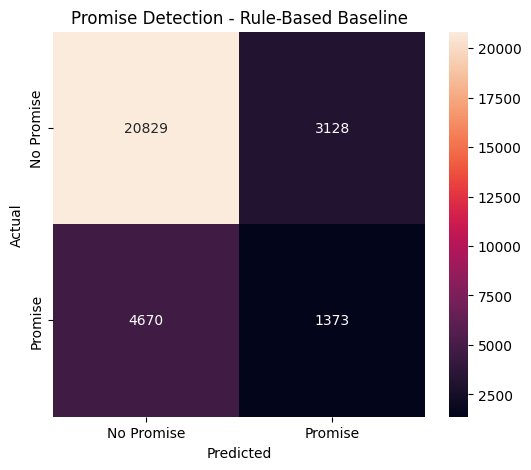

In [255]:
# ============================================
# STEP 10.6 - CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Promise", "Promise"],
    yticklabels=["No Promise", "Promise"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Promise Detection - Rule-Based Baseline")

plt.show()

In [256]:
# ============================================
# STEP 10.7 - SAVE PROMISE DETECTOR CONFIG
# ============================================

import json

PROMISE_PATTERNS_PATH = os.path.join(
    CONFIG_DIR,
    "promise_patterns.json"
)

with open(PROMISE_PATTERNS_PATH, "w") as file:
    json.dump(
        PROMISE_PATTERNS,
        file,
        indent=4
    )

print(f"Promise patterns saved to:")
print(PROMISE_PATTERNS_PATH)

Promise patterns saved to:
/content/promiseguard_ai/config/promise_patterns.json


In [257]:
X = df_clean["text_for_nlp"]
y = df_clean["ground_truth_has_promise"]

print(f"Total samples: {len(X)}")
print(f"Promise samples: {y.sum()}")
print(f"Non-promise samples: {(y == 0).sum()}")

Total samples: 30000
Promise samples: 6043
Non-promise samples: 23957


In [258]:
# ============================================
# STEP 11.2 - TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 24000
Testing samples:  6000


In [259]:
# ============================================
# STEP 11.3 - TF-IDF VECTORIZATION
# ============================================

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape:  {X_test_tfidf.shape}")

Training matrix shape: (24000, 26123)
Testing matrix shape:  (6000, 26123)


In [260]:
promise_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

promise_classifier.fit(
    X_train_tfidf,
    y_train
)

print("Promise classifier trained successfully.")

Promise classifier trained successfully.


In [261]:
# ============================================
# STEP 11.5 - PROMISE PREDICTIONS
# ============================================

y_pred_ml = promise_classifier.predict(X_test_tfidf)

print("Predictions generated successfully.")

Predictions generated successfully.


In [262]:
# ============================================
# STEP 11.6 - EVALUATE ML CLASSIFIER
# ============================================

print("Promise Detection - TF-IDF + Logistic Regression")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_ml):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_ml, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_ml, zero_division=0):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_ml, zero_division=0):.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_ml,
        target_names=["No Promise", "Promise"],
        zero_division=0
    )
)

Promise Detection - TF-IDF + Logistic Regression
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000

Classification Report:
              precision    recall  f1-score   support

  No Promise       1.00      1.00      1.00      4791
     Promise       1.00      1.00      1.00      1209

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



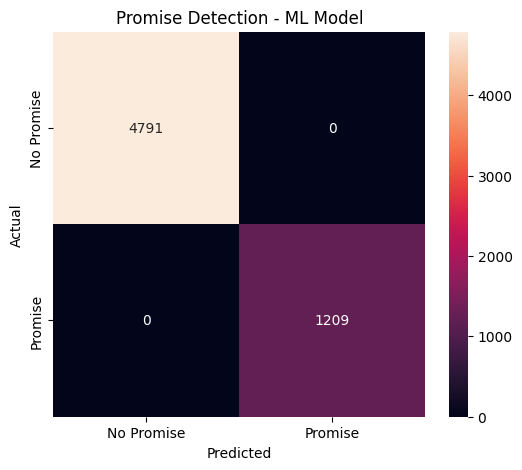

In [263]:
# ============================================
# STEP 11.7 - CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred_ml)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Promise", "Promise"],
    yticklabels=["No Promise", "Promise"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Promise Detection - ML Model")

plt.show()

In [264]:
# ============================================
# STEP 11.8 - COMPARE PROMISE DETECTORS
# ============================================

rule_pred_test = (
    X_test
    .apply(detect_promise_rule_based)
    .astype(int)
)

comparison = pd.DataFrame({
    "Model": [
        "Rule-Based",
        "TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, rule_pred_test),
        accuracy_score(y_test, y_pred_ml)
    ],
    "Precision": [
        precision_score(y_test, rule_pred_test, zero_division=0),
        precision_score(y_test, y_pred_ml, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rule_pred_test, zero_division=0),
        recall_score(y_test, y_pred_ml, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, rule_pred_test, zero_division=0),
        f1_score(y_test, y_pred_ml, zero_division=0)
    ]
})

display(comparison.round(3))

,Model,Accuracy,Precision,Recall,F1
0,Rule-Based,0.745,0.321,0.239,0.274
1,TF-IDF + Logistic Regression,1.000,1.000,1.000,1.000


In [265]:
# ============================================
# STEP 11.9 - SAVE PROMISE MODEL
# ============================================

import joblib

VECTORIZER_PATH = os.path.join(
    MODELS_DIR,
    "promise_tfidf_vectorizer.joblib"
)

CLASSIFIER_PATH = os.path.join(
    MODELS_DIR,
    "promise_classifier.joblib"
)

joblib.dump(
    tfidf_vectorizer,
    VECTORIZER_PATH
)

joblib.dump(
    promise_classifier,
    CLASSIFIER_PATH
)

print("Promise detection artifacts saved:")
print(f"- {VECTORIZER_PATH}")
print(f"- {CLASSIFIER_PATH}")

Promise detection artifacts saved:
- /content/promiseguard_ai/models/promise_tfidf_vectorizer.joblib
- /content/promiseguard_ai/models/promise_classifier.joblib


In [266]:
# ============================================
# STEP 11.10 - TEST SAVED MODEL
# ============================================

loaded_vectorizer = joblib.load(VECTORIZER_PATH)
loaded_classifier = joblib.load(CLASSIFIER_PATH)

sample_message = [
    "I will process your refund of $200 tomorrow."
]

sample_features = loaded_vectorizer.transform(sample_message)

prediction = loaded_classifier.predict(sample_features)[0]
probability = loaded_classifier.predict_proba(sample_features)[0][1]

print(f"Message: {sample_message[0]}")
print(f"Prediction: {'Promise' if prediction == 1 else 'No Promise'}")
print(f"Promise probability: {probability:.3f}")

Message: I will process your refund of $200 tomorrow.
Prediction: Promise
Promise probability: 0.810


In [267]:
# ============================================
# STEP 12.1 - INSPECT EXTRACTION LABELS
# ============================================

extraction_columns = [
    "message_text",
    "ground_truth_has_promise",
    "ground_truth_action",
    "ground_truth_deadline",
    "ground_truth_amount",
    "promise_type"
]

display(
    df_clean[
        extraction_columns
    ]
    .loc[df_clean["ground_truth_has_promise"] == 1]
    .head(20)
)

,message_text,ground_truth_has_promise,ground_truth_action,ground_truth_deadline,ground_truth_amount,promise_type
3,"Looking at request 023757, I’ll trace the fail...",1,trace the failed payment,today,NaN,Follow-up
4,"On the current thread (031676), Let me call yo...",1,call you with the outcome,today,NaN,Follow-up
11,"In this account context, I will ask our securi...",1,ask our security team to verify the login,tomorrow,NaN,Resolution
13,Regarding reference 102947: Hi — Leave this wi...,1,send the corrected invoice,today,25.0,Investigation
21,"In this account context, I’ll make sure I rest...",1,restore the missing entitlement,today,NaN,Follow-up
22,"Looking at request 174218, count on me to upda...",1,update the access settings,later this week,NaN,Fulfillment
29,"On the support thread, i will ask our security...",1,ask our security team to verify the login,tomorrow,NaN,Resolution
31,"On the support thread, Hi — I can take this fo...",1,coordinate the refund review,tomorrow,NaN,Communication
34,Quick note on ticket 269246: Leave this with m...,1,trace the failed payment,NaN,NaN,Communication
36,Quick note on ticket 285084: Count on me to co...,1,confirm the cancellation details,today,NaN,Follow-up


In [268]:
# ============================================
# STEP 12.2 - PROMISE-ONLY DATASET
# ============================================

promise_df = df_clean[
    df_clean["ground_truth_has_promise"] == 1
].copy()

promise_df = promise_df.reset_index(drop=True)

print(f"Promise messages: {len(promise_df)}")

display(
    promise_df[
        [
            "message_text",
            "ground_truth_action",
            "ground_truth_deadline",
            "ground_truth_amount"
        ]
    ].head(10)
)

Promise messages: 6043


,message_text,ground_truth_action,ground_truth_deadline,ground_truth_amount
0,"Looking at request 023757, I’ll trace the fail...",trace the failed payment,today,NaN
1,"On the current thread (031676), Let me call yo...",call you with the outcome,today,NaN
2,"In this account context, I will ask our securi...",ask our security team to verify the login,tomorrow,NaN
3,Regarding reference 102947: Hi — Leave this wi...,send the corrected invoice,today,25.0
4,"In this account context, I’ll make sure I rest...",restore the missing entitlement,today,NaN
5,"Looking at request 174218, count on me to upda...",update the access settings,later this week,NaN
6,"On the support thread, i will ask our security...",ask our security team to verify the login,tomorrow,NaN
7,"On the support thread, Hi — I can take this fo...",coordinate the refund review,tomorrow,NaN
8,Quick note on ticket 269246: Leave this with m...,trace the failed payment,NaN,NaN
9,Quick note on ticket 285084: Count on me to co...,confirm the cancellation details,today,NaN


In [269]:
# ============================================
# STEP 12.3 - ACTION VOCABULARY
# ============================================

action_values = (
    promise_df["ground_truth_action"]
    .dropna()
    .astype(str)
    .str.strip()
)

action_vocabulary = sorted(
    action_values.unique()
)

print("Actions found in the dataset:\n")

for action in action_vocabulary:
    print(f"- {action}")

Actions found in the dataset:

- arrange a replacement unit
- ask our security team to verify the login
- attach the requested export
- call you with the outcome
- check the delivery scan
- confirm the cancellation details
- coordinate the refund review
- raise this with the engineering queue
- restore the missing entitlement
- review the account history
- send a written explanation
- send the corrected invoice
- share the diagnostic notes
- trace the failed payment
- update the access settings


In [270]:
# ============================================
# STEP 12.4 - ACTION EXTRACTION
# ============================================

def extract_action(text, actions):
    """
    Extract the first known action appearing
    in the message.
    """

    if not isinstance(text, str):
        return None

    text_lower = text.lower()

    for action in actions:
        if action.lower() in text_lower:
            return action

    return None

In [271]:
# ============================================
# STEP 12.5 - APPLY ACTION EXTRACTION
# ============================================

promise_df["predicted_action"] = promise_df[
    "message_text"
].apply(
    lambda text: extract_action(
        text,
        action_vocabulary
    )
)

display(
    promise_df[
        [
            "message_text",
            "ground_truth_action",
            "predicted_action"
        ]
    ].head(20)
)

,message_text,ground_truth_action,predicted_action
0,"Looking at request 023757, I’ll trace the fail...",trace the failed payment,trace the failed payment
1,"On the current thread (031676), Let me call yo...",call you with the outcome,call you with the outcome
2,"In this account context, I will ask our securi...",ask our security team to verify the login,ask our security team to verify the login
3,Regarding reference 102947: Hi — Leave this wi...,send the corrected invoice,send the corrected invoice
4,"In this account context, I’ll make sure I rest...",restore the missing entitlement,restore the missing entitlement
5,"Looking at request 174218, count on me to upda...",update the access settings,update the access settings
6,"On the support thread, i will ask our security...",ask our security team to verify the login,ask our security team to verify the login
7,"On the support thread, Hi — I can take this fo...",coordinate the refund review,coordinate the refund review
8,Quick note on ticket 269246: Leave this with m...,trace the failed payment,trace the failed payment
9,Quick note on ticket 285084: Count on me to co...,confirm the cancellation details,confirm the cancellation details


In [272]:
# ============================================
# STEP 12.6 - AMOUNT EXTRACTION
# ============================================

AMOUNT_PATTERN = re.compile(
    r"""
    (?:
        \$\s?[\d,]+(?:\.\d{1,2})?
        |
        [\d,]+(?:\.\d{1,2})?\s?(?:usd|dollars?)
    )
    """,
    re.IGNORECASE | re.VERBOSE
)


def extract_amount(text):
    """
    Extract the first monetary amount from text.
    """

    if not isinstance(text, str):
        return None

    match = AMOUNT_PATTERN.search(text)

    if not match:
        return None

    amount_text = match.group(0)

    # Remove currency words/symbols
    cleaned = re.sub(
        r"[^\d.]",
        "",
        amount_text
    )

    try:
        return float(cleaned)
    except ValueError:
        return None

In [273]:
# ============================================
# STEP 12.7 - TEST AMOUNT EXTRACTION
# ============================================

test_messages = [
    "I will refund $200 tomorrow.",
    "We will credit 150 dollars to your account.",
    "Your refund of $1,250 will be processed Friday.",
    "I will check this for you."
]

for message in test_messages:
    print(
        f"Message: {message}\n"
        f"Amount:  {extract_amount(message)}\n"
    )

Message: I will refund $200 tomorrow.
Amount:  200.0

Message: We will credit 150 dollars to your account.
Amount:  150.0

Message: Your refund of $1,250 will be processed Friday.
Amount:  1250.0

Message: I will check this for you.
Amount:  None



In [274]:
# ============================================
# STEP 12.8 - APPLY AMOUNT EXTRACTION
# ============================================

promise_df["predicted_amount"] = (
    promise_df["message_text"]
    .apply(extract_amount)
)

display(
    promise_df[
        [
            "message_text",
            "ground_truth_amount",
            "predicted_amount"
        ]
    ].head(20)
)

,message_text,ground_truth_amount,predicted_amount
0,"Looking at request 023757, I’ll trace the fail...",NaN,None
1,"On the current thread (031676), Let me call yo...",NaN,None
2,"In this account context, I will ask our securi...",NaN,None
3,Regarding reference 102947: Hi — Leave this wi...,25.0,None
4,"In this account context, I’ll make sure I rest...",NaN,None
5,"Looking at request 174218, count on me to upda...",NaN,None
6,"On the support thread, i will ask our security...",NaN,None
7,"On the support thread, Hi — I can take this fo...",NaN,None
8,Quick note on ticket 269246: Leave this with m...,NaN,None
9,Quick note on ticket 285084: Count on me to co...,NaN,None


In [275]:
# ============================================
# STEP 12.9 - INSPECT DEADLINE TYPES
# ============================================

print("Deadline types:")

display(
    promise_df[
        "deadline_type"
    ]
    .value_counts(dropna=False)
)

Deadline types:


,count
deadline_type,
relative,3787
sla-like,976
calendar,685
none,595


In [276]:
# Inspect actual deadline examples

display(
    promise_df[
        [
            "message_text",
            "ground_truth_deadline",
            "deadline_type"
        ]
    ].head(30)
)

,message_text,ground_truth_deadline,deadline_type
0,"Looking at request 023757, I’ll trace the fail...",today,relative
1,"On the current thread (031676), Let me call yo...",today,relative
2,"In this account context, I will ask our securi...",tomorrow,relative
3,Regarding reference 102947: Hi — Leave this wi...,today,relative
4,"In this account context, I’ll make sure I rest...",today,relative
5,"Looking at request 174218, count on me to upda...",later this week,relative
6,"On the support thread, i will ask our security...",tomorrow,relative
7,"On the support thread, Hi — I can take this fo...",tomorrow,relative
8,Quick note on ticket 269246: Leave this with m...,NaN,none
9,Quick note on ticket 285084: Count on me to co...,today,relative


In [277]:
# ============================================
# STEP 12.10 - BASIC DEADLINE EXTRACTION
# ============================================

RELATIVE_DEADLINE_PATTERNS = [
    r"\btoday\b",
    r"\btomorrow\b",
    r"\byesterday\b",
    r"\btonight\b",
    r"\bthis week\b",
    r"\bnext week\b",
    r"\bwithin \d+ (?:hour|hours|day|days)\b",
    r"\bin \d+ (?:hour|hours|day|days)\b",
    r"\bby \d{1,2}(?::\d{2})?\s?(?:am|pm)?\b"
]


def extract_deadline_text(text):
    """
    Extract a deadline expression from a message.
    Returns the textual deadline expression.
    """

    if not isinstance(text, str):
        return None

    for pattern in RELATIVE_DEADLINE_PATTERNS:
        match = re.search(
            pattern,
            text,
            re.IGNORECASE
        )

        if match:
            return match.group(0)

    return None

In [278]:
# ============================================
# STEP 12.11 - APPLY DEADLINE EXTRACTION
# ============================================

promise_df["predicted_deadline_text"] = (
    promise_df["message_text"]
    .apply(extract_deadline_text)
)

display(
    promise_df[
        [
            "message_text",
            "ground_truth_deadline",
            "predicted_deadline_text"
        ]
    ].head(30)
)

,message_text,ground_truth_deadline,predicted_deadline_text
0,"Looking at request 023757, I’ll trace the fail...",today,today
1,"On the current thread (031676), Let me call yo...",today,today
2,"In this account context, I will ask our securi...",tomorrow,tomorrow
3,Regarding reference 102947: Hi — Leave this wi...,today,today
4,"In this account context, I’ll make sure I rest...",today,today
5,"Looking at request 174218, count on me to upda...",later this week,this week
6,"On the support thread, i will ask our security...",tomorrow,tomorrow
7,"On the support thread, Hi — I can take this fo...",tomorrow,tomorrow
8,Quick note on ticket 269246: Leave this with m...,NaN,None
9,Quick note on ticket 285084: Count on me to co...,today,today


In [279]:
# ============================================
# STEP 12.12 - CREATE PROMISE RECORD
# ============================================

promise_df["extracted_promise"] = (
    promise_df["predicted_action"].notna()
    | promise_df["predicted_deadline_text"].notna()
    | promise_df["predicted_amount"].notna()
)

promise_records = promise_df[
    [
        "conversation_id",
        "message_id",
        "customer_id",
        "timestamp",
        "message_text",
        "predicted_action",
        "predicted_deadline_text",
        "predicted_amount"
    ]
].copy()

display(promise_records.head(20))

,conversation_id,message_id,customer_id,timestamp,message_text,predicted_action,predicted_deadline_text,predicted_amount
0,CONV-000002,MSG-000002-01,CUST-0372,2026-03-03 09:34:00,"Looking at request 023757, I’ll trace the fail...",trace the failed payment,today,None
1,CONV-000002,MSG-000002-02,CUST-0372,2026-03-03 09:40:00,"On the current thread (031676), Let me call yo...",call you with the outcome,today,None
2,CONV-000004,MSG-000004-02,CUST-0440,2026-04-01 08:53:00,"In this account context, I will ask our securi...",ask our security team to verify the login,tomorrow,None
3,CONV-000004,MSG-000004-04,CUST-0440,2026-04-01 09:29:00,Regarding reference 102947: Hi — Leave this wi...,send the corrected invoice,today,None
4,CONV-000006,MSG-000006-03,CUST-0945,2026-07-19 22:49:00,"In this account context, I’ll make sure I rest...",restore the missing entitlement,today,None
5,CONV-000007,MSG-000007-01,CUST-0277,2026-02-12 00:38:00,"Looking at request 174218, count on me to upda...",update the access settings,this week,None
6,CONV-000008,MSG-000008-04,CUST-0726,2026-01-12 20:00:00,"On the support thread, i will ask our security...",ask our security team to verify the login,tomorrow,None
7,CONV-000008,MSG-000008-06,CUST-0726,2026-01-12 20:29:01,"On the support thread, Hi — I can take this fo...",coordinate the refund review,tomorrow,None
8,CONV-000008,MSG-000008-09,CUST-0726,2026-01-12 21:11:01,Quick note on ticket 269246: Leave this with m...,trace the failed payment,None,None
9,CONV-000009,MSG-000009-02,CUST-0657,2026-01-27 09:15:00,Quick note on ticket 285084: Count on me to co...,confirm the cancellation details,today,None


In [280]:
# ============================================
# STEP 12.13 - SAVE EXTRACTION CONFIGURATION
# ============================================

EXTRACTION_CONFIG = {
    "action_vocabulary": action_vocabulary,
    "amount_pattern": AMOUNT_PATTERN.pattern,
    "relative_deadline_patterns": RELATIVE_DEADLINE_PATTERNS
}

EXTRACTION_CONFIG_PATH = os.path.join(
    CONFIG_DIR,
    "extraction_config.json"
)

with open(EXTRACTION_CONFIG_PATH, "w") as file:
    json.dump(
        EXTRACTION_CONFIG,
        file,
        indent=4
    )

print(
    f"Extraction configuration saved to:\n"
    f"{EXTRACTION_CONFIG_PATH}"
)

Extraction configuration saved to:
/content/promiseguard_ai/config/extraction_config.json


In [281]:
# ============================================
# STEP 13.1 - INSPECT DEADLINES
# ============================================

deadline_examples = promise_df[
    promise_df["ground_truth_deadline"].notna()
][
    [
        "timestamp",
        "message_text",
        "ground_truth_deadline",
        "deadline_type"
    ]
]

display(
    deadline_examples.head(30)
)

,timestamp,message_text,ground_truth_deadline,deadline_type
0,2026-03-03 09:34:00,"Looking at request 023757, I’ll trace the fail...",today,relative
1,2026-03-03 09:40:00,"On the current thread (031676), Let me call yo...",today,relative
2,2026-04-01 08:53:00,"In this account context, I will ask our securi...",tomorrow,relative
3,2026-04-01 09:29:00,Regarding reference 102947: Hi — Leave this wi...,today,relative
4,2026-07-19 22:49:00,"In this account context, I’ll make sure I rest...",today,relative
5,2026-02-12 00:38:00,"Looking at request 174218, count on me to upda...",later this week,relative
6,2026-01-12 20:00:00,"On the support thread, i will ask our security...",tomorrow,relative
7,2026-01-12 20:29:01,"On the support thread, Hi — I can take this fo...",tomorrow,relative
9,2026-01-27 09:15:00,Quick note on ticket 285084: Count on me to co...,today,relative
10,2026-05-01 23:10:00,"On the support thread, I can take this forward...",later this week,relative


In [282]:
# ============================================
# STEP 13.2 - NORMALIZE DEADLINE
# ============================================

def normalize_deadline(deadline_text, message_timestamp):
    """
    Convert a textual relative deadline into
    a normalized datetime where possible.
    """

    if not deadline_text or pd.isna(message_timestamp):
        return pd.NaT

    deadline = deadline_text.lower().strip()

    message_date = pd.Timestamp(message_timestamp)

    # Today
    if deadline == "today":
        return message_date.normalize()

    # Tomorrow
    if deadline == "tomorrow":
        return (
            message_date + pd.Timedelta(days=1)
        ).normalize()

    # Yesterday
    if deadline == "yesterday":
        return (
            message_date - pd.Timedelta(days=1)
        ).normalize()

    # This week
    if deadline == "this week":
        return (
            message_date
            + pd.Timedelta(days=6)
        ).normalize()

    # Next week
    if deadline == "next week":
        return (
            message_date
            + pd.Timedelta(days=7)
        ).normalize()

    # Within X days/hours
    match = re.search(
        r"(?:within|in)\s+(\d+)\s+(hour|hours|day|days)",
        deadline
    )

    if match:
        amount = int(match.group(1))
        unit = match.group(2)

        if "hour" in unit:
            return message_date + pd.Timedelta(hours=amount)

        if "day" in unit:
            return (
                message_date
                + pd.Timedelta(days=amount)
            )

    return pd.NaT

In [283]:
# ============================================
# STEP 13.3 - APPLY DEADLINE NORMALIZATION
# ============================================

promise_df["normalized_deadline"] = promise_df.apply(
    lambda row: normalize_deadline(
        row["predicted_deadline_text"],
        row["timestamp"]
    ),
    axis=1
)

display(
    promise_df[
        [
            "timestamp",
            "message_text",
            "predicted_deadline_text",
            "normalized_deadline"
        ]
    ].head(30)
)

,timestamp,message_text,predicted_deadline_text,normalized_deadline
0,2026-03-03 09:34:00,"Looking at request 023757, I’ll trace the fail...",today,2026-03-03
1,2026-03-03 09:40:00,"On the current thread (031676), Let me call yo...",today,2026-03-03
2,2026-04-01 08:53:00,"In this account context, I will ask our securi...",tomorrow,2026-04-02
3,2026-04-01 09:29:00,Regarding reference 102947: Hi — Leave this wi...,today,2026-04-01
4,2026-07-19 22:49:00,"In this account context, I’ll make sure I rest...",today,2026-07-19
5,2026-02-12 00:38:00,"Looking at request 174218, count on me to upda...",this week,2026-02-18
6,2026-01-12 20:00:00,"On the support thread, i will ask our security...",tomorrow,2026-01-13
7,2026-01-12 20:29:01,"On the support thread, Hi — I can take this fo...",tomorrow,2026-01-13
8,2026-01-12 21:11:01,Quick note on ticket 269246: Leave this with m...,None,NaT
9,2026-01-27 09:15:00,Quick note on ticket 285084: Count on me to co...,today,2026-01-27


In [284]:
# ============================================
# STEP 13.4 - INSPECT EMPLOYEE INFORMATION
# ============================================

employee_candidates = [
    column
    for column in df_clean.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "employee",
            "agent",
            "staff",
            "representative"
        ]
    )
]

print("Potential employee-related columns:")

for column in employee_candidates:
    print(f"- {column}")

Potential employee-related columns:
- employee_name


In [285]:
# Inspect message roles and possible employee identifiers

display(
    df_clean[
        [
            "message_role",
            "message_text"
        ]
    ].head(20)
)

,message_role,message_text
0,Employee,I understand another specialist will check the...
1,Customer,"In this account context, The charge appeared o..."
2,Customer,"If the review is approved, the delivery case c..."
3,Employee,"Looking at request 023757, I’ll trace the fail..."
4,Customer,"On the current thread (031676), Let me call yo..."
5,Employee,"On the current thread (039595), This feature i..."
6,Employee,"On the current thread (047514), Hi, This featu..."
7,Customer,"In this account context, A future review may h..."
8,Employee,The platform will automatically update the tic...
9,Customer,"On the support thread, The request is currentl..."


In [286]:
# ============================================
# STEP 13.5 - BUILD PROMISE RECORD
# ============================================

promise_records = promise_df[
    [
        "conversation_id",
        "message_id",
        "customer_id",
        "timestamp",
        "message_text",
        "predicted_action",
        "predicted_amount",
        "predicted_deadline_text",
        "normalized_deadline"
    ]
].copy()

promise_records = promise_records.rename(
    columns={
        "message_text": "promise_text",
        "predicted_action": "action",
        "predicted_amount": "amount",
        "predicted_deadline_text": "deadline_text"
    }
)

display(promise_records.head(20))

,conversation_id,message_id,customer_id,timestamp,promise_text,action,amount,deadline_text,normalized_deadline
0,CONV-000002,MSG-000002-01,CUST-0372,2026-03-03 09:34:00,"Looking at request 023757, I’ll trace the fail...",trace the failed payment,None,today,2026-03-03
1,CONV-000002,MSG-000002-02,CUST-0372,2026-03-03 09:40:00,"On the current thread (031676), Let me call yo...",call you with the outcome,None,today,2026-03-03
2,CONV-000004,MSG-000004-02,CUST-0440,2026-04-01 08:53:00,"In this account context, I will ask our securi...",ask our security team to verify the login,None,tomorrow,2026-04-02
3,CONV-000004,MSG-000004-04,CUST-0440,2026-04-01 09:29:00,Regarding reference 102947: Hi — Leave this wi...,send the corrected invoice,None,today,2026-04-01
4,CONV-000006,MSG-000006-03,CUST-0945,2026-07-19 22:49:00,"In this account context, I’ll make sure I rest...",restore the missing entitlement,None,today,2026-07-19
5,CONV-000007,MSG-000007-01,CUST-0277,2026-02-12 00:38:00,"Looking at request 174218, count on me to upda...",update the access settings,None,this week,2026-02-18
6,CONV-000008,MSG-000008-04,CUST-0726,2026-01-12 20:00:00,"On the support thread, i will ask our security...",ask our security team to verify the login,None,tomorrow,2026-01-13
7,CONV-000008,MSG-000008-06,CUST-0726,2026-01-12 20:29:01,"On the support thread, Hi — I can take this fo...",coordinate the refund review,None,tomorrow,2026-01-13
8,CONV-000008,MSG-000008-09,CUST-0726,2026-01-12 21:11:01,Quick note on ticket 269246: Leave this with m...,trace the failed payment,None,None,NaT
9,CONV-000009,MSG-000009-02,CUST-0657,2026-01-27 09:15:00,Quick note on ticket 285084: Count on me to co...,confirm the cancellation details,None,today,2026-01-27


In [287]:
# ============================================
# STEP 14.1 — Inspect Sentiment Labels
# ============================================

print("Customer sentiment distribution:")
print(df_clean["customer_sentiment"].value_counts(dropna=False))

print("\nUnique sentiment labels:")
print(df_clean["customer_sentiment"].dropna().unique())

Customer sentiment distribution:
customer_sentiment
Neutral       13858
Positive       6506
Concerned      5407
Frustrated     4229
Name: count, dtype: int64

Unique sentiment labels:
['Positive' 'Neutral' 'Frustrated' 'Concerned']


In [288]:
# ============================================
# STEP 14.2 — Inspect Sentiment Examples
# ============================================

sentiment_examples = df_clean[
    ["message_text", "customer_sentiment"]
].dropna().sample(
    min(15, df_clean["customer_sentiment"].notna().sum()),
    random_state=42
)

sentiment_examples

,message_text,customer_sentiment
2308,The published SLA says the team will review th...,Neutral
22404,The published SLA says the team will review th...,Concerned
23397,"For the record, The previous update was record...",Concerned
25058,Regarding reference 437668: I’ll coordinate th...,Frustrated
2664,"Looking at request 096573, A future review may...",Positive
8511,I understand another specialist will check the...,Concerned
5148,"On the support thread, The request is currentl...",Neutral
7790,The published SLA says the team will review th...,Concerned
11311,"Could you send the refund review tomorrow, or ...",Neutral
19043,"Looking at request 804067, I will confirm the ...",Neutral


In [289]:
# ============================================
# STEP 14.3 — Load Sentiment Model
# ============================================

SENTIMENT_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL_NAME,
    tokenizer=SENTIMENT_MODEL_NAME
)

print("Sentiment model loaded successfully!")
print("Model:", SENTIMENT_MODEL_NAME)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment model loaded successfully!
Model: cardiffnlp/twitter-roberta-base-sentiment-latest


In [290]:
# ============================================
# STEP 14.4 — Test Sentiment Model
# ============================================

test_messages = [
    "Thank you, everything was resolved perfectly.",
    "I am very disappointed with this service.",
    "I will check the issue and get back to you tomorrow."
]

for message in test_messages:
    result = sentiment_pipeline(message)[0]

    print("Message:", message)
    print("Sentiment:", result["label"])
    print("Confidence:", round(result["score"], 4))
    print("-" * 60)

Message: Thank you, everything was resolved perfectly.
Sentiment: positive
Confidence: 0.9007
------------------------------------------------------------
Message: I am very disappointed with this service.
Sentiment: negative
Confidence: 0.9381
------------------------------------------------------------
Message: I will check the issue and get back to you tomorrow.
Sentiment: neutral
Confidence: 0.8501
------------------------------------------------------------


In [291]:
# ============================================
# STEP 14.5 — Predict Sentiment
# ============================================

def predict_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({
            "predicted_sentiment": None,
            "sentiment_score": None
        })

    result = sentiment_pipeline(text[:512])[0]

    label = result["label"].lower()
    score = result["score"]

    return pd.Series({
        "predicted_sentiment": label,
        "sentiment_score": score
    })


sentiment_results = df_clean["message_text"].apply(predict_sentiment)

df_clean = pd.concat(
    [df_clean, sentiment_results],
    axis=1
)

print("Sentiment predictions completed!")
df_clean[
    [
        "message_text",
        "predicted_sentiment",
        "sentiment_score"
    ]
].head(10)

Sentiment predictions completed!


,message_text,predicted_sentiment,sentiment_score
0,I understand another specialist will check the...,neutral,0.879423
1,"In this account context, The charge appeared o...",neutral,0.931870
2,"If the review is approved, the delivery case c...",neutral,0.849463
3,"Looking at request 023757, I’ll trace the fail...",negative,0.576468
4,"On the current thread (031676), Let me call yo...",neutral,0.941767
5,"On the current thread (039595), This feature i...",neutral,0.784494
6,"On the current thread (047514), Hi, This featu...",neutral,0.684943
7,"In this account context, A future review may h...",neutral,0.909798
8,The platform will automatically update the tic...,neutral,0.915623
9,"On the support thread, The request is currentl...",neutral,0.919776


In [292]:
# ============================================
# STEP 14.6 — Sentiment Distribution
# ============================================

print("Predicted sentiment distribution:")
print(
    df_clean["predicted_sentiment"]
    .value_counts(dropna=False)
)

print("\nAverage confidence:")
print(
    round(
        df_clean["sentiment_score"].dropna().mean(),
        4
    )
)

Predicted sentiment distribution:
predicted_sentiment
neutral     29168
negative      711
positive      121
Name: count, dtype: int64

Average confidence:
0.8795


In [293]:
# ============================================
# STEP 14.7 — Evaluate Sentiment
# ============================================

sentiment_eval = df_clean[
    ["customer_sentiment", "predicted_sentiment"]
].dropna()

print("Ground-truth labels:")
print(sentiment_eval["customer_sentiment"].value_counts())

print("\nPredicted labels:")
print(sentiment_eval["predicted_sentiment"].value_counts())

Ground-truth labels:
customer_sentiment
Neutral       13858
Positive       6506
Concerned      5407
Frustrated     4229
Name: count, dtype: int64

Predicted labels:
predicted_sentiment
neutral     29168
negative      711
positive      121
Name: count, dtype: int64


In [294]:
# ============================================
# STEP 14.8 — Save Sentiment Configuration
# ============================================

import json

sentiment_config = {
    "model_name": SENTIMENT_MODEL_NAME,
    "task": "sentiment-analysis",
    "input_column": "message_text",
    "output_label_column": "predicted_sentiment",
    "output_score_column": "sentiment_score"
}

sentiment_config_path = os.path.join(
    CONFIG_DIR,
    "sentiment_config.json"
)

with open(sentiment_config_path, "w") as f:
    json.dump(
        sentiment_config,
        f,
        indent=4
    )

print("Sentiment configuration saved to:")
print(sentiment_config_path)

Sentiment configuration saved to:
/content/promiseguard_ai/config/sentiment_config.json


In [295]:
# ============================================
# STEP 15.1 — Inspect Promise Outcomes
# ============================================

print("Ground-truth promise status:")
print(
    promise_df["ground_truth_status"]
    .value_counts(dropna=False)
)

print("\nBroken promise distribution:")
print(
    promise_df["is_broken_promise"]
    .value_counts(dropna=False)
)

print("\nRisk level distribution:")
print(
    promise_df["risk_level"]
    .value_counts(dropna=False)
)

Ground-truth promise status:
ground_truth_status
commitment_open    4046
missed              728
in_progress         635
completed           634
Name: count, dtype: int64

Broken promise distribution:
is_broken_promise
False    5315
True      728
Name: count, dtype: int64

Risk level distribution:
risk_level
Low       3369
Medium    1880
High       794
Name: count, dtype: int64


In [296]:
# ============================================
# STEP 15.2 — Inspect Promise Outcomes
# ============================================

promise_outcome_examples = promise_df[
    [
        "message_text",
        "ground_truth_action",
        "ground_truth_deadline",
        "ground_truth_status",
        "is_broken_promise",
        "recommended_action"
    ]
].sample(
    min(20, len(promise_df)),
    random_state=42
)

promise_outcome_examples

,message_text,ground_truth_action,ground_truth_deadline,ground_truth_status,is_broken_promise,recommended_action
3070,"For the record, i will arrange a replacement u...",arrange a replacement unit,today,commitment_open,False,Offer proactive update
1820,"On the current thread (454344), I’ll make sure...",call you with the outcome,today,commitment_open,False,Monitor
4919,Quick note on ticket 496127: I’ll personally c...,call you with the outcome,today,in_progress,False,Escalate to owner
3414,"On the support thread, I will coordinate the r...",coordinate the refund review,tomorrow,in_progress,False,Escalate to owner
3950,"For the record, I can take this forward and re...",restore the missing entitlement,today,commitment_open,False,Respond normally
228,Regarding reference 384168: I’m going to arran...,arrange a replacement unit,today,commitment_open,False,Offer proactive update
2446,"In this account context, Count on me to raise ...",raise this with the engineering queue,within 24 hours,in_progress,False,Monitor
2404,"On the support thread, Leave this with me — I’...",send a written explanation,later this week,completed,False,Offer proactive update
2932,"On the support thread, i’ll share the diagnost...",share the diagnostic notes,today,commitment_open,False,Offer proactive update
763,Quick note on ticket 106359: Leave this with m...,share the diagnostic notes,by Friday,missed,True,Offer proactive update


In [297]:
# ============================================
# STEP 15.3 — Basic Promise Status Detection
# ============================================

def detect_promise_status(
    deadline,
    message_timestamp,
    current_time=None
):
    """
    Determine whether a promise is:
    - overdue
    - pending
    - no_deadline
    """

    if pd.isna(deadline):
        return "no_deadline"

    if current_time is None:
        current_time = pd.Timestamp.now()

    deadline = pd.Timestamp(deadline)
    message_timestamp = pd.Timestamp(message_timestamp)

    if current_time > deadline:
        return "overdue"

    return "pending"

In [298]:
# ============================================
# STEP 15.4 — Apply Status Detection
# ============================================

promise_records["detected_status"] = promise_records.apply(
    lambda row: detect_promise_status(
        row["normalized_deadline"],
        row["timestamp"]
    ),
    axis=1
)

promise_records[
    [
        "promise_text",
        "deadline_text",
        "normalized_deadline",
        "detected_status"
    ]
].head(15)

,promise_text,deadline_text,normalized_deadline,detected_status
0,"Looking at request 023757, I’ll trace the fail...",today,2026-03-03,overdue
1,"On the current thread (031676), Let me call yo...",today,2026-03-03,overdue
2,"In this account context, I will ask our securi...",tomorrow,2026-04-02,overdue
3,Regarding reference 102947: Hi — Leave this wi...,today,2026-04-01,overdue
4,"In this account context, I’ll make sure I rest...",today,2026-07-19,overdue
5,"Looking at request 174218, count on me to upda...",this week,2026-02-18,overdue
6,"On the support thread, i will ask our security...",tomorrow,2026-01-13,overdue
7,"On the support thread, Hi — I can take this fo...",tomorrow,2026-01-13,overdue
8,Quick note on ticket 269246: Leave this with m...,None,NaT,no_deadline
9,Quick note on ticket 285084: Count on me to co...,today,2026-01-27,overdue


In [299]:
# ============================================
# STEP 15.5 — Calculate Days Overdue
# ============================================

def calculate_days_overdue(deadline, reference_time=None):
    if pd.isna(deadline):
        return 0

    if reference_time is None:
        reference_time = pd.Timestamp.now()

    deadline = pd.Timestamp(deadline)
    reference_time = pd.Timestamp(reference_time)

    difference = reference_time - deadline

    if difference.total_seconds() <= 0:
        return 0

    return difference.total_seconds() / (24 * 60 * 60)


promise_records["days_overdue"] = promise_records[
    "normalized_deadline"
].apply(calculate_days_overdue)

promise_records[
    [
        "promise_text",
        "normalized_deadline",
        "detected_status",
        "days_overdue"
    ]
].head(15)

,promise_text,normalized_deadline,detected_status,days_overdue
0,"Looking at request 023757, I’ll trace the fail...",2026-03-03,overdue,189.681296
1,"On the current thread (031676), Let me call yo...",2026-03-03,overdue,189.681296
2,"In this account context, I will ask our securi...",2026-04-02,overdue,159.681296
3,Regarding reference 102947: Hi — Leave this wi...,2026-04-01,overdue,160.681296
4,"In this account context, I’ll make sure I rest...",2026-07-19,overdue,51.681296
5,"Looking at request 174218, count on me to upda...",2026-02-18,overdue,202.681296
6,"On the support thread, i will ask our security...",2026-01-13,overdue,238.681296
7,"On the support thread, Hi — I can take this fo...",2026-01-13,overdue,238.681296
8,Quick note on ticket 269246: Leave this with m...,NaT,no_deadline,0.000000
9,Quick note on ticket 285084: Count on me to co...,2026-01-27,overdue,224.681296


In [300]:
# ============================================
# STEP 15.6 — Broken Promise Detection
# ============================================

promise_records["detected_broken_promise"] = (
    promise_records["detected_status"] == "overdue"
).astype(int)

print(
    "Detected broken promises:",
    promise_records["detected_broken_promise"].sum()
)

print(
    "Total detected promises:",
    len(promise_records)
)

Detected broken promises: 4763
Total detected promises: 6043


In [301]:
# ============================================
# STEP 15.7 — Evaluate Broken Promise Detection
# ============================================

evaluation_df = promise_df[
    [
        "conversation_id",
        "message_id",
        "is_broken_promise"
    ]
].copy()

evaluation_df = evaluation_df.merge(
    promise_records[
        [
            "conversation_id",
            "message_id",
            "detected_broken_promise"
        ]
    ],
    on=["conversation_id", "message_id"],
    how="left"
)

evaluation_df["detected_broken_promise"] = (
    evaluation_df["detected_broken_promise"]
    .fillna(0)
    .astype(int)
)

y_true = evaluation_df["is_broken_promise"].astype(int)
y_pred = evaluation_df["detected_broken_promise"].astype(int)

print("Accuracy:",
      round(accuracy_score(y_true, y_pred), 4))

print("Precision:",
      round(precision_score(y_true, y_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_true, y_pred, zero_division=0), 4))

print("F1:",
      round(f1_score(y_true, y_pred, zero_division=0), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.2843
Precision: 0.1224
Recall: 0.8008
F1: 0.2123

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.21      0.34      5315
           1       0.12      0.80      0.21       728

    accuracy                           0.28      6043
   macro avg       0.50      0.51      0.28      6043
weighted avg       0.79      0.28      0.33      6043



In [302]:
# ============================================
# STEP 15.8 — Semantic Similarity Model
# ============================================

SIMILARITY_MODEL_NAME = "all-MiniLM-L6-v2"

similarity_model = SentenceTransformer(
    SIMILARITY_MODEL_NAME
)

print("Similarity model loaded successfully!")
print("Model:", SIMILARITY_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Similarity model loaded successfully!
Model: all-MiniLM-L6-v2


In [303]:
# ============================================
# STEP 15.9 — Fulfillment Signals
# ============================================

FULFILLMENT_PATTERNS = [
    r"\bcompleted\b",
    r"\bdone\b",
    r"\bfinished\b",
    r"\bsent\b",
    r"\bprocessed\b",
    r"\bresolved\b",
    r"\bfixed\b",
    r"\bdelivered\b",
    r"\brefunded\b",
    r"\bissued\b",
    r"\bupdated\b",
    r"\bconfirmed\b",
    r"\bcompleted successfully\b",
    r"\bhas been sent\b",
    r"\bhas been processed\b",
    r"\bhas been resolved\b"
]

FULFILLMENT_REGEX = re.compile(
    "|".join(FULFILLMENT_PATTERNS),
    re.IGNORECASE
)


def contains_fulfillment_signal(text):
    if not isinstance(text, str):
        return False

    return bool(FULFILLMENT_REGEX.search(text))

In [304]:
# ============================================
# STEP 15.10 — Test Fulfillment Detection
# ============================================

test_messages = [
    "I have sent the invoice.",
    "The refund has been processed.",
    "I will check this tomorrow.",
    "Let me investigate the issue."
]

for message in test_messages:
    print(
        message,
        "->",
        contains_fulfillment_signal(message)
    )

I have sent the invoice. -> True
The refund has been processed. -> True
I will check this tomorrow. -> False
Let me investigate the issue. -> False


In [305]:
# ============================================
# STEP 15.11 — Track Promise Fulfillment
# ============================================

def track_promise_fulfillment(
    promise_row,
    conversation_df,
    similarity_threshold=0.45
):
    """
    Look for later messages that may indicate
    the original promise was fulfilled.
    """

    promise_time = pd.Timestamp(promise_row["timestamp"])
    promise_text = promise_row["promise_text"]

    later_messages = conversation_df[
        conversation_df["timestamp"] > promise_time
    ].copy()

    if later_messages.empty:
        return {
            "fulfilled": False,
            "fulfillment_message_id": None,
            "fulfillment_similarity": 0.0
        }

    promise_embedding = similarity_model.encode(
        [promise_text],
        convert_to_numpy=True
    )

    message_embeddings = similarity_model.encode(
        later_messages["message_text"].fillna("").tolist(),
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        promise_embedding,
        message_embeddings
    )[0]

    later_messages["similarity"] = similarities

    # Prefer messages with explicit fulfillment language
    fulfillment_messages = later_messages[
        later_messages["message_text"].apply(
            contains_fulfillment_signal
        )
    ]

    if not fulfillment_messages.empty:
        best_match = fulfillment_messages.sort_values(
            "similarity",
            ascending=False
        ).iloc[0]

        if best_match["similarity"] >= similarity_threshold:
            return {
                "fulfilled": True,
                "fulfillment_message_id": best_match["message_id"],
                "fulfillment_similarity": float(
                    best_match["similarity"]
                )
            }

    return {
        "fulfilled": False,
        "fulfillment_message_id": None,
        "fulfillment_similarity": 0.0
    }

In [306]:
# ============================================
# STEP 15.12 — Apply Promise Tracking
# ============================================

tracking_results = []

for _, promise in promise_records.iterrows():

    conversation = df_clean[
        df_clean["conversation_id"] == promise["conversation_id"]
    ].copy()

    result = track_promise_fulfillment(
        promise,
        conversation
    )

    tracking_results.append(result)


tracking_results_df = pd.DataFrame(tracking_results)

promise_records = pd.concat(
    [
        promise_records.reset_index(drop=True),
        tracking_results_df.reset_index(drop=True)
    ],
    axis=1
)

promise_records[
    [
        "promise_text",
        "detected_status",
        "detected_broken_promise",
        "fulfilled",
        "fulfillment_message_id",
        "fulfillment_similarity"
    ]
].head(20)

,promise_text,detected_status,detected_broken_promise,fulfilled,fulfillment_message_id,fulfillment_similarity
0,"Looking at request 023757, I’ll trace the fail...",overdue,1,False,None,0.0
1,"On the current thread (031676), Let me call yo...",overdue,1,False,None,0.0
2,"In this account context, I will ask our securi...",overdue,1,False,None,0.0
3,Regarding reference 102947: Hi — Leave this wi...,overdue,1,False,None,0.0
4,"In this account context, I’ll make sure I rest...",overdue,1,False,None,0.0
5,"Looking at request 174218, count on me to upda...",overdue,1,False,None,0.0
6,"On the support thread, i will ask our security...",overdue,1,False,None,0.0
7,"On the support thread, Hi — I can take this fo...",overdue,1,False,None,0.0
8,Quick note on ticket 269246: Leave this with m...,no_deadline,0,False,None,0.0
9,Quick note on ticket 285084: Count on me to co...,overdue,1,False,None,0.0


In [307]:
# ============================================
# STEP 15.13 — Final Broken Promise Baseline
# ============================================

promise_records["detected_broken_promise"] = (
    (promise_records["detected_status"] == "overdue")
    & (~promise_records["fulfilled"])
).astype(int)

print(
    "Potentially broken promises:",
    promise_records["detected_broken_promise"].sum()
)

print(
    "Fulfilled promises detected:",
    promise_records["fulfilled"].sum()
)

Potentially broken promises: 4747
Fulfilled promises detected: 21


In [308]:
# ============================================
# STEP 15.14 — Save Promise Tracking Results
# ============================================

promise_records_path = os.path.join(
    OUTPUTS_DIR,
    "promise_records_tracked.csv"
)

promise_records.to_csv(
    promise_records_path,
    index=False
)

print("Saved tracked promise records to:")
print(promise_records_path)

Saved tracked promise records to:
/content/promiseguard_ai/outputs/promise_records_tracked.csv


In [309]:
# ============================================
# STEP 15.15 — Save Tracking Configuration
# ============================================

tracking_config = {
    "similarity_model": SIMILARITY_MODEL_NAME,
    "similarity_threshold": 0.45,
    "fulfillment_patterns": FULFILLMENT_PATTERNS,
    "logic": {
        "overdue_without_fulfillment": "potentially_broken",
        "overdue_with_fulfillment": "fulfilled"
    }
}

tracking_config_path = os.path.join(
    CONFIG_DIR,
    "promise_tracking_config.json"
)

with open(tracking_config_path, "w") as f:
    json.dump(
        tracking_config,
        f,
        indent=4
    )

print("Tracking configuration saved to:")
print(tracking_config_path)

Tracking configuration saved to:
/content/promiseguard_ai/config/promise_tracking_config.json


In [310]:
# ============================================
# STEP 16.1 — Customer Risk Features
# ============================================

customer_features = (
    df_clean
    .groupby("customer_id")
    .agg(
        customer_name=("customer_name", "first"),
        account_mrr=("account_mrr", "first"),
        historical_churn_risk=(
            "historical_churn_risk_score",
            "first"
        ),
        avg_sentiment_score=(
            "sentiment_score",
            "mean"
        ),
        message_count=(
            "message_id",
            "count"
        )
    )
    .reset_index()
)

# Promise statistics
promise_stats = (
    promise_records
    .groupby("customer_id")
    .agg(
        total_promises=("message_id", "count"),
        broken_promises=(
            "detected_broken_promise",
            "sum"
        ),
        fulfilled_promises=(
            "fulfilled",
            "sum"
        ),
        overdue_promises=(
            "detected_status",
            lambda x: (x == "overdue").sum()
        )
    )
    .reset_index()
)

customer_features = customer_features.merge(
    promise_stats,
    on="customer_id",
    how="left"
)

customer_features = customer_features.fillna(0)

customer_features.head()

,customer_id,customer_name,account_mrr,historical_churn_risk,avg_sentiment_score,message_count,total_promises,broken_promises,fulfilled_promises,overdue_promises
0,CUST-0000,Amina Hassan,49,0.072,0.876266,28,5.0,5.0,0.0,5.0
1,CUST-0001,Omar Rashad,29,0.588,0.902956,39,8.0,6.0,0.0,6.0
2,CUST-0002,Nour Nasser,999,0.998,0.918117,15,1.0,1.0,0.0,1.0
3,CUST-0003,Youssef Nabil,499,0.970,0.873019,23,5.0,3.0,0.0,3.0
4,CUST-0004,Mariam Yassin,249,0.929,0.884821,41,12.0,9.0,0.0,9.0


In [311]:
# ============================================
# STEP 16.2 — Promise Risk Metrics
# ============================================

customer_features["broken_promise_rate"] = np.where(
    customer_features["total_promises"] > 0,
    customer_features["broken_promises"]
    / customer_features["total_promises"],
    0
)

customer_features["overdue_rate"] = np.where(
    customer_features["total_promises"] > 0,
    customer_features["overdue_promises"]
    / customer_features["total_promises"],
    0
)

customer_features[
    [
        "customer_id",
        "total_promises",
        "broken_promises",
        "broken_promise_rate",
        "overdue_rate"
    ]
].head(10)

,customer_id,total_promises,broken_promises,broken_promise_rate,overdue_rate
0,CUST-0000,5.0,5.0,1.000000,1.000000
1,CUST-0001,8.0,6.0,0.750000,0.750000
2,CUST-0002,1.0,1.0,1.000000,1.000000
3,CUST-0003,5.0,3.0,0.600000,0.600000
4,CUST-0004,12.0,9.0,0.750000,0.750000
5,CUST-0005,5.0,5.0,1.000000,1.000000
6,CUST-0006,8.0,7.0,0.875000,0.875000
7,CUST-0007,5.0,4.0,0.800000,0.800000
8,CUST-0008,7.0,5.0,0.714286,0.714286
9,CUST-0009,14.0,12.0,0.857143,0.857143


In [312]:
# ============================================
# STEP 16.3 — Customer Risk Score
# ============================================

customer_features["risk_score"] = (
    customer_features["historical_churn_risk"] * 0.35
    +
    customer_features["broken_promise_rate"] * 100 * 0.30
    +
    customer_features["overdue_rate"] * 100 * 0.20
    +
    (1 - customer_features["avg_sentiment_score"]) * 100 * 0.15
)

customer_features["risk_score"] = (
    customer_features["risk_score"]
    .clip(0, 100)
)

customer_features[
    [
        "customer_id",
        "risk_score",
        "historical_churn_risk",
        "broken_promise_rate",
        "overdue_rate"
    ]
].sort_values(
    "risk_score",
    ascending=False
).head(10)

,customer_id,risk_score,historical_churn_risk,broken_promise_rate,overdue_rate
43,CUST-0043,53.339451,0.693,1.0,1.0
560,CUST-0560,53.185324,0.075,1.0,1.0
90,CUST-0090,52.770528,0.668,1.0,1.0
788,CUST-0789,52.746047,0.986,1.0,1.0
48,CUST-0048,52.699473,0.742,1.0,1.0
710,CUST-0710,52.681806,0.494,1.0,1.0
728,CUST-0729,52.680059,0.498,1.0,1.0
582,CUST-0582,52.586757,0.989,1.0,1.0
101,CUST-0101,52.541713,0.376,1.0,1.0
366,CUST-0366,52.539575,0.802,1.0,1.0


In [313]:
# ============================================
# STEP 16.4 — Risk Levels
# ============================================

def assign_risk_level(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


customer_features["predicted_risk_level"] = (
    customer_features["risk_score"]
    .apply(assign_risk_level)
)

print(
    customer_features["predicted_risk_level"]
    .value_counts()
)

predicted_risk_level
Medium    565
Low       434
Name: count, dtype: int64


In [314]:
# ============================================
# STEP 16.5 — Revenue At Risk
# ============================================

customer_features["revenue_at_risk"] = np.where(
    customer_features["predicted_risk_level"] == "High",
    customer_features["account_mrr"],
    np.where(
        customer_features["predicted_risk_level"] == "Medium",
        customer_features["account_mrr"] * 0.5,
        0
    )
)

print(
    "Estimated Revenue at Risk:",
    round(
        customer_features["revenue_at_risk"].sum(),
        2
    )
)

Estimated Revenue at Risk: 119860.0


In [315]:
# ============================================
# STEP 16.6 — Prepare Risk Model Dataset
# ============================================

risk_df = customer_features.copy()

print("Risk dataset shape:", risk_df.shape)

risk_df[
    [
        "customer_id",
        "account_mrr",
        "historical_churn_risk",
        "avg_sentiment_score",
        "total_promises",
        "broken_promises",
        "overdue_promises"
    ]
].head()

Risk dataset shape: (999, 15)


,customer_id,account_mrr,historical_churn_risk,avg_sentiment_score,total_promises,broken_promises,overdue_promises
0,CUST-0000,49,0.072,0.876266,5.0,5.0,5.0
1,CUST-0001,29,0.588,0.902956,8.0,6.0,6.0
2,CUST-0002,999,0.998,0.918117,1.0,1.0,1.0
3,CUST-0003,499,0.970,0.873019,5.0,3.0,3.0
4,CUST-0004,249,0.929,0.884821,12.0,9.0,9.0


In [316]:
# ============================================
# STEP 16.7 — Create Ground Truth Risk Target
# ============================================

risk_target = (
    df_clean
    .groupby("customer_id")["risk_level"]
    .first()
    .reset_index()
)

risk_target.columns = [
    "customer_id",
    "ground_truth_risk_level"
]

risk_df = risk_df.merge(
    risk_target,
    on="customer_id",
    how="left"
)

print(
    risk_df["ground_truth_risk_level"]
    .value_counts(dropna=False)
)

ground_truth_risk_level
Low       572
Medium    296
High      131
Name: count, dtype: int64


In [317]:
# ============================================
# STEP 16.8 — Risk Model Features
# ============================================

RISK_FEATURES = [
    "account_mrr",
    "historical_churn_risk",
    "avg_sentiment_score",
    "total_promises",
    "broken_promises",
    "fulfilled_promises",
    "overdue_promises",
    "broken_promise_rate",
    "overdue_rate",
    "message_count"
]

X_risk = risk_df[RISK_FEATURES]
y_risk = risk_df["ground_truth_risk_level"]

print("Features:")
print(RISK_FEATURES)

print("\nX shape:", X_risk.shape)
print("y shape:", y_risk.shape)

Features:
['account_mrr', 'historical_churn_risk', 'avg_sentiment_score', 'total_promises', 'broken_promises', 'fulfilled_promises', 'overdue_promises', 'broken_promise_rate', 'overdue_rate', 'message_count']

X shape: (999, 10)
y shape: (999,)


In [318]:
import subprocess

# Assuming app.py is a Streamlit application
# You might need to install Streamlit first: !pip install streamlit

# Run the Streamlit application
# This will provide a local URL and a public URL (ngrok) for access
subprocess.Popen(["streamlit", "run", "/content/promiseguard_ai/app.py"])


Training samples: 799
Testing samples: 200


In [319]:
# ============================================
# STEP 16.10 — Train Risk Model
# ============================================

risk_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk
)

print("Risk model trained successfully!")

Risk model trained successfully!


In [320]:
# ============================================
# STEP 16.11 — Evaluate Risk Model
# ============================================

y_pred_risk = risk_model.predict(X_test_risk)

print("Accuracy:",
      round(accuracy_score(y_test_risk, y_pred_risk), 4))

print("F1 Score:",
      round(
          f1_score(
              y_test_risk,
              y_pred_risk,
              average="weighted",
              zero_division=0
          ),
          4
      ))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_risk,
        y_pred_risk,
        zero_division=0
    )
)

Accuracy: 0.47
F1 Score: 0.4525

Classification Report:

              precision    recall  f1-score   support

        High       0.17      0.15      0.16        26
         Low       0.59      0.68      0.63       115
      Medium       0.27      0.20      0.23        59

    accuracy                           0.47       200
   macro avg       0.34      0.35      0.34       200
weighted avg       0.44      0.47      0.45       200



In [321]:
# ============================================
# STEP 16.12 — Feature Importance
# ============================================

feature_importance = pd.DataFrame({
    "feature": RISK_FEATURES,
    "importance": risk_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
2,avg_sentiment_score,0.204270
1,historical_churn_risk,0.198910
9,message_count,0.159008
0,account_mrr,0.108708
3,total_promises,0.082222
8,overdue_rate,0.071358
7,broken_promise_rate,0.065367
4,broken_promises,0.055445
6,overdue_promises,0.053031
5,fulfilled_promises,0.001680


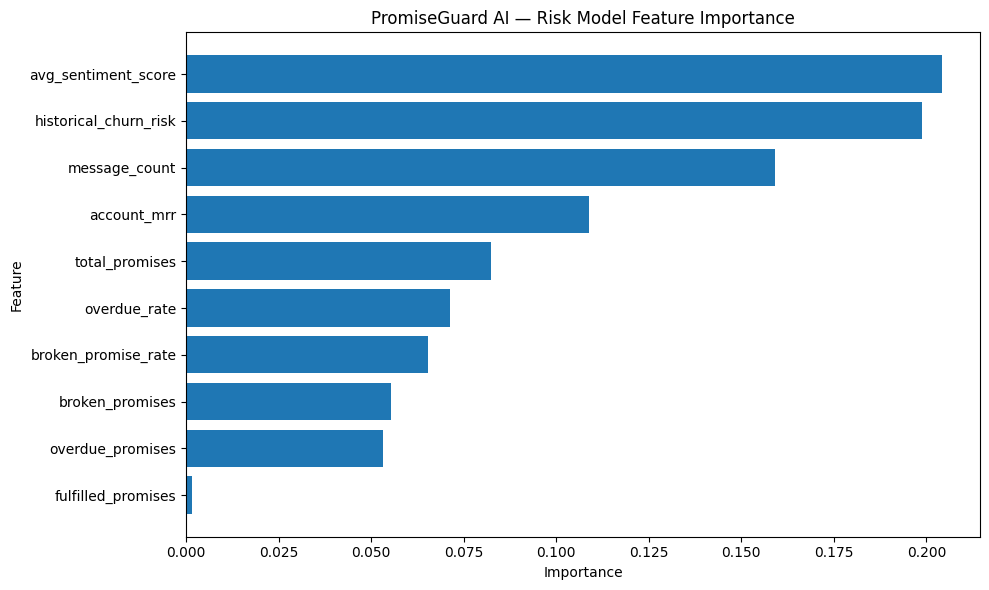

In [322]:
# ============================================
# STEP 16.13 — Feature Importance Plot
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("PromiseGuard AI — Risk Model Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [323]:
# ============================================
# STEP 16.14 — Predict Customer Risk
# ============================================

risk_df["ml_risk_level"] = risk_model.predict(
    X_risk
)

risk_probabilities = risk_model.predict_proba(X_risk)

risk_df["ml_risk_confidence"] = (
    risk_probabilities.max(axis=1)
)

risk_df[
    [
        "customer_id",
        "customer_name",
        "ml_risk_level",
        "ml_risk_confidence"
    ]
].sort_values(
    "ml_risk_confidence",
    ascending=False
).head(10)

,customer_id,customer_name,ml_risk_level,ml_risk_confidence
71,CUST-0071,Maya Aziz,Low,0.785499
811,CUST-0812,Ziad Mahmoud,Low,0.777313
404,CUST-0404,Mariam Yassin,Low,0.754832
53,CUST-0053,Farah Khalil,Low,0.752681
36,CUST-0036,Samir Fouad,Low,0.744869
376,CUST-0376,Samir Fouad,Low,0.736863
917,CUST-0918,Khaled Kamel,Low,0.728318
362,CUST-0362,Nour Nasser,Low,0.722927
788,CUST-0789,Salma Saleh,Low,0.720004
366,CUST-0366,Karim Fahmy,Low,0.696631


In [324]:
# ============================================
# STEP 16.15 — Save Risk Model
# ============================================

import joblib

risk_model_path = os.path.join(
    MODELS_DIR,
    "promiseguard_risk_model.joblib"
)

joblib.dump(
    risk_model,
    risk_model_path
)

print("Risk model saved to:")
print(risk_model_path)

Risk model saved to:
/content/promiseguard_ai/models/promiseguard_risk_model.joblib


In [325]:
# ============================================
# STEP 16.16 — Save Risk Model Configuration
# ============================================

risk_config = {
    "features": RISK_FEATURES,
    "model": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 8,
    "random_state": 42
}

risk_config_path = os.path.join(
    CONFIG_DIR,
    "risk_model_config.json"
)

with open(risk_config_path, "w") as f:
    json.dump(
        risk_config,
        f,
        indent=4
    )

print("Risk configuration saved to:")
print(risk_config_path)

Risk configuration saved to:
/content/promiseguard_ai/config/risk_model_config.json


In [326]:
# ============================================
# STEP 17.1 — End-to-End PromiseGuard Pipeline
# ============================================

def promiseguard_analyze(
    text,
    timestamp=None,
    customer_id=None,
    customer_name=None,
    account_mrr=0,
    historical_churn_risk=0
):
    """
    Analyze a single customer message.

    Returns:
        Dictionary containing:
        - promise detection
        - action
        - amount
        - deadline
        - sentiment
        - risk-related information
    """

    if timestamp is None:
        timestamp = pd.Timestamp.now()

    timestamp = pd.Timestamp(timestamp)

    # ----------------------------------------
    # 1. Clean text
    # ----------------------------------------
    clean_text = str(text).strip()

    # ----------------------------------------
    # 2. Promise detection
    # ----------------------------------------
    promise_prediction = detect_promise_rule_based(
        clean_text
    )

    # ----------------------------------------
    # 3. Action extraction
    # ----------------------------------------
    action = extract_action(
        clean_text,
        action_vocabulary
    )

    # ----------------------------------------
    # 4. Amount extraction
    # ----------------------------------------
    amount = extract_amount(clean_text)

    # ----------------------------------------
    # 5. Deadline extraction
    # ----------------------------------------
    deadline_text = extract_deadline_text(
        clean_text
    )

    normalized_deadline = normalize_deadline(
        deadline_text,
        timestamp
    )

    # ----------------------------------------
    # 6. Sentiment
    # ----------------------------------------
    sentiment_result = sentiment_pipeline(
        clean_text[:512]
    )[0]

    sentiment = sentiment_result["label"].lower()
    sentiment_score = sentiment_result["score"]

    # ----------------------------------------
    # 7. Promise status
    # ----------------------------------------
    if promise_prediction and pd.notna(
        normalized_deadline
    ):
        status = detect_promise_status(
            normalized_deadline,
            timestamp
        )
    elif promise_prediction:
        status = "no_deadline"
    else:
        status = "not_a_promise"

    # ----------------------------------------
    # 8. Return result
    # ----------------------------------------
    return {
        "customer_id": customer_id,
        "customer_name": customer_name,
        "timestamp": timestamp,
        "message_text": text,

        "has_promise": int(promise_prediction),

        "action": action,
        "amount": amount,

        "deadline_text": deadline_text,
        "normalized_deadline": normalized_deadline,

        "sentiment": sentiment,
        "sentiment_score": sentiment_score,

        "status": status,

        "account_mrr": account_mrr,
        "historical_churn_risk": historical_churn_risk
    }


print("PromiseGuard pipeline created successfully!")

PromiseGuard pipeline created successfully!


In [327]:
# ============================================
# STEP 17.2 — Test End-to-End Pipeline
# ============================================

test_result = promiseguard_analyze(
    text="I will process your $200 refund tomorrow.",
    timestamp="2026-09-08 10:00:00",
    customer_id="TEST001",
    customer_name="Test Customer",
    account_mrr=500,
    historical_churn_risk=35
)

test_result

{'customer_id': 'TEST001',
 'customer_name': 'Test Customer',
 'timestamp': Timestamp('2026-09-08 10:00:00'),
 'message_text': 'I will process your $200 refund tomorrow.',
 'has_promise': 1,
 'action': None,
 'amount': 200.0,
 'deadline_text': 'tomorrow',
 'normalized_deadline': Timestamp('2026-09-09 00:00:00'),
 'sentiment': 'neutral',
 'sentiment_score': 0.8235010504722595,
 'status': 'pending',
 'account_mrr': 500,
 'historical_churn_risk': 35}

In [328]:
# ============================================
# STEP 17.3 — Pipeline Output DataFrame
# ============================================

test_result_df = pd.DataFrame([test_result])

test_result_df

,customer_id,customer_name,timestamp,message_text,has_promise,action,amount,deadline_text,normalized_deadline,sentiment,sentiment_score,status,account_mrr,historical_churn_risk
0,TEST001,Test Customer,2026-09-08 10:00:00,I will process your $200 refund tomorrow.,1,None,200.0,tomorrow,2026-09-09,neutral,0.823501,pending,500,35


In [329]:
# ============================================
# STEP 17.4 — ML Promise Detection
# ============================================

def predict_promise_ml(text):
    if not isinstance(text, str) or not text.strip():
        return {
            "prediction": 0,
            "probability": 0.0
        }

    text_vector = tfidf_vectorizer.transform(
        [text]
    )

    prediction = promise_classifier.predict(
        text_vector
    )[0]

    probability = promise_classifier.predict_proba(
        text_vector
    ).max()

    return {
        "prediction": int(prediction),
        "probability": float(probability)
    }


ml_test = predict_promise_ml(
    "I will process your refund tomorrow."
)

ml_test

{'prediction': 1, 'probability': 0.6181303219983529}

In [330]:
# ============================================
# STEP 17.5 — ML-Based PromiseGuard Pipeline
# ============================================

def promiseguard_analyze_ml(
    text,
    timestamp=None,
    customer_id=None,
    customer_name=None,
    account_mrr=0,
    historical_churn_risk=0
):

    if timestamp is None:
        timestamp = pd.Timestamp.now()

    timestamp = pd.Timestamp(timestamp)

    clean_text = str(text).strip()

    # ----------------------------------------
    # Promise detection
    # ----------------------------------------
    promise_result = predict_promise_ml(
        clean_text
    )

    has_promise = promise_result["prediction"]
    promise_confidence = promise_result["probability"]

    # ----------------------------------------
    # Extraction
    # ----------------------------------------
    action = extract_action(
        clean_text,
        action_vocabulary
    )

    amount = extract_amount(clean_text)

    deadline_text = extract_deadline_text(
        clean_text
    )

    normalized_deadline = normalize_deadline(
        deadline_text,
        timestamp
    )

    # ----------------------------------------
    # Sentiment
    # ----------------------------------------
    sentiment_result = sentiment_pipeline(
        clean_text[:512]
    )[0]

    sentiment = sentiment_result["label"].lower()
    sentiment_score = sentiment_result["score"]

    # ----------------------------------------
    # Status
    # ----------------------------------------
    if has_promise and pd.notna(
        normalized_deadline
    ):
        status = detect_promise_status(
            normalized_deadline,
            timestamp
        )

    elif has_promise:
        status = "no_deadline"

    else:
        status = "not_a_promise"

    return {
        "customer_id": customer_id,
        "customer_name": customer_name,
        "timestamp": timestamp,
        "message_text": text,

        "has_promise": has_promise,
        "promise_confidence": promise_confidence,

        "action": action,
        "amount": amount,

        "deadline_text": deadline_text,
        "normalized_deadline": normalized_deadline,

        "sentiment": sentiment,
        "sentiment_score": sentiment_score,

        "status": status,

        "account_mrr": account_mrr,
        "historical_churn_risk": historical_churn_risk
    }


print("ML-based PromiseGuard pipeline ready!")

ML-based PromiseGuard pipeline ready!


In [331]:
# ============================================
# STEP 17.6 — Final Pipeline Test
# ============================================

examples = [
    "I will send the invoice tomorrow.",
    "Thank you, that solved my issue.",
    "We will refund $150 within 2 days.",
    "I'm still waiting for someone to help me."
]

for text in examples:

    result = promiseguard_analyze_ml(
        text=text,
        timestamp="2026-09-08 12:00:00"
    )

    print("\nMessage:", text)
    print("Promise:", result["has_promise"])
    print("Confidence:", round(
        result["promise_confidence"], 3
    ))
    print("Action:", result["action"])
    print("Amount:", result["amount"])
    print("Deadline:", result["deadline_text"])
    print("Sentiment:", result["sentiment"])
    print("Status:", result["status"])
    print("-" * 70)


Message: I will send the invoice tomorrow.
Promise: 1
Confidence: 0.767
Action: None
Amount: None
Deadline: tomorrow
Sentiment: neutral
Status: pending
----------------------------------------------------------------------

Message: Thank you, that solved my issue.
Promise: 0
Confidence: 0.805
Action: None
Amount: None
Deadline: None
Sentiment: positive
Status: not_a_promise
----------------------------------------------------------------------

Message: We will refund $150 within 2 days.
Promise: 0
Confidence: 0.776
Action: None
Amount: 150.0
Deadline: within 2 days
Sentiment: neutral
Status: not_a_promise
----------------------------------------------------------------------

Message: I'm still waiting for someone to help me.
Promise: 0
Confidence: 0.777
Action: None
Amount: None
Deadline: None
Sentiment: negative
Status: not_a_promise
----------------------------------------------------------------------


In [332]:
# ============================================
# STEP 17.7 — Save Pipeline Configuration
# ============================================

pipeline_config = {
    "promise_detection": {
        "method": "TF-IDF + Logistic Regression",
        "vectorizer": "promise_tfidf_vectorizer.joblib",
        "model": "promise_classifier.joblib"
    },

    "information_extraction": {
        "action_extraction": "vocabulary matching",
        "amount_extraction": "regex",
        "deadline_extraction": "regex + normalization"
    },

    "sentiment": {
        "model": SENTIMENT_MODEL_NAME
    },

    "promise_tracking": {
        "similarity_model": SIMILARITY_MODEL_NAME,
        "similarity_threshold": 0.45
    },

    "risk_model": {
        "model": "promiseguard_risk_model.joblib",
        "features": RISK_FEATURES
    }
}

pipeline_config_path = os.path.join(
    CONFIG_DIR,
    "pipeline_config.json"
)

with open(pipeline_config_path, "w") as f:
    json.dump(
        pipeline_config,
        f,
        indent=4
    )

print("Pipeline configuration saved:")
print(pipeline_config_path)

Pipeline configuration saved:
/content/promiseguard_ai/config/pipeline_config.json


In [338]:
# ============================================
# BACKUP PROMISEGUARD AI PROJECT
# ============================================

import shutil
import os

PROJECT_DIR = "/content/promiseguard_ai"

zip_path = shutil.make_archive(
    "/content/promiseguard_ai_backup",
    "zip",
    PROJECT_DIR
)

print("Backup created successfully!")
print(zip_path)
print(f"Size: {os.path.getsize(zip_path) / (1024 * 1024):.2f} MB")

Backup created successfully!
/content/promiseguard_ai_backup.zip
Size: 2.67 MB


In [339]:
from google.colab import files

files.download("/content/promiseguard_ai_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# STEP 13 - SENTIMENT ANALYSIS (TRANSFORMERS)
# ============================================
print("Loading Sentiment Analysis Pipeline...")
# We use a lightweight distilled BERT model for fast sentiment scoring
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def predict_sentiment(text):
    try:
        # Truncate text to avoid model length errors
        result = sentiment_pipeline(text[:512])[0]
        return result['label'] # Returns 'POSITIVE' or 'NEGATIVE'
    except Exception as e:
        return "NEUTRAL"

# Apply to a sample or the full dataframe
print("Applying sentiment analysis to messages...")
df_clean['predicted_sentiment'] = df_clean['message_text'].apply(predict_sentiment)

display(df_clean[['message_text', 'customer_sentiment', 'predicted_sentiment']].head(5))

In [ ]:
# ============================================
# STEP 14 - ENTITY EXTRACTION (DEADLINE & AMOUNT)
# ============================================
# Note: Ensure you have run !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

def extract_promise_entities(text):
    doc = nlp(text)
    
    # Extract deadlines using spaCy NER (DATE, TIME)
    dates = [ent.text for ent in doc.ents if ent.label_ in ['DATE', 'TIME']]
    
    # Fallback/Supplemental Regex for common support timeframes
    if not dates:
        time_regex = re.findall(r'\b(today|tomorrow|next week|by friday|within \d+ hours)\b', text, re.IGNORECASE)
        dates = time_regex if time_regex else [None]

    # Extract Amounts using Regex (e.g., $50, 100 USD)
    amounts = re.findall(r'\$\d+(?:\.\d{2})?|\d+(?:\.\d{2})?\s*(?:USD|dollars)', text, re.IGNORECASE)
    
    return {
        'extracted_deadline': dates[0] if dates else None,
        'extracted_amount': amounts[0] if amounts else None
    }

print("Extracting Deadlines and Amounts...")
extracted_df = df_clean['message_text'].apply(lambda x: pd.Series(extract_promise_entities(x)))
df_clean = pd.concat([df_clean, extracted_df], axis=1)

display(df_clean[df_clean['ground_truth_has_promise'] == 1][['message_text', 'extracted_deadline', 'extracted_amount']].head(5))

In [ ]:
# ============================================
# STEP 15 - SEMANTIC SIMILARITY LINKING
# ============================================
print("Loading SentenceTransformer for Semantic Linking...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all messages to link follow-ups to original promises
embeddings = embedder.encode(df_clean['message_text'].tolist(), show_progress_bar=True)
df_clean['embeddings'] = list(embeddings)

def find_related_promise(current_msg_idx, conversation_id):
    """Finds the most semantically similar past promise in the same conversation."""
    conv_history = df_clean[(df_clean['conversation_id'] == conversation_id) & 
                            (df_clean.index < current_msg_idx) & 
                            (df_clean['promise_prediction_rule'] == True)]
    
    if conv_history.empty:
        return None
        
    current_emb = np.array(df_clean.at[current_msg_idx, 'embeddings']).reshape(1, -1)
    history_embs = np.stack(conv_history['embeddings'].values)
    
    similarities = cosine_similarity(current_emb, history_embs)[0]
    best_match_idx = np.argmax(similarities)
    
    # Return the index of the most similar past promise if similarity > 0.6
    if similarities[best_match_idx] > 0.60:
        return conv_history.index[best_match_idx]
    return None

In [ ]:
# ============================================
# STEP 16 - STATUS TRACKING & DEADLINE MONITORING
# ============================================
# Simulating the current system date for demonstration
CURRENT_SYSTEM_TIME = pd.to_datetime('2026-09-09')

def calculate_status(row):
    if row['ground_truth_has_promise'] == 0:
        return 'not_applicable'
        
    msg_time = pd.to_datetime(row['timestamp'])
    
    # Calculate a rough deadline timestamp based on SLA or extracted deadline
    if pd.notna(row['sla_hours']):
        deadline_time = msg_time + pd.Timedelta(hours=row['sla_hours'])
    else:
        deadline_time = msg_time + pd.Timedelta(hours=24) # Default fallback
        
    # Check if the current time has bypassed the deadline
    if CURRENT_SYSTEM_TIME > deadline_time:
        return 'missed' # Broken promise
    else:
        return 'commitment_open'

df_clean['calculated_status'] = df_clean.apply(calculate_status, axis=1)
df_clean['predicted_is_broken'] = df_clean['calculated_status'] == 'missed'

print(f"Total Predicted Broken Promises: {df_clean['predicted_is_broken'].sum()}")

In [ ]:
# ============================================
# STEP 17 - RISK SCORING ENGINE (MACHINE LEARNING)
# ============================================
print("Training Random Forest Risk Classifier...")

# Prepare features: Churn score, MRR, Sentiment, and whether a promise was broken
le_sentiment = LabelEncoder()
df_clean['sentiment_encoded'] = le_sentiment.fit_transform(df_clean['customer_sentiment'])

feature_cols = ['historical_churn_risk_score', 'account_mrr', 'sentiment_encoded', 'predicted_is_broken']
X_risk = df_clean[feature_cols].fillna(0)
y_risk = df_clean['risk_level'] # Target: Low, Medium, High

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_risk, y_risk, test_size=0.2, random_state=42)

risk_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
risk_classifier.fit(X_train_r, y_train_r)

print(f"Risk Prediction Accuracy: {accuracy_score(y_test_r, risk_classifier.predict(X_test_r)):.3f}")

# Predict risk for the whole dataset
df_clean['predicted_risk_level'] = risk_classifier.predict(X_risk)

# Save the risk model
joblib.dump(risk_classifier, os.path.join(MODELS_DIR, "risk_classifier.joblib"))